<p style="color:#FFF; background:#07D; padding:12px; font-size:20px; font-style:italic; text-align:center">
<span style="width:49%; display:inline-block; text-align:center">Leila  & Fabarika </span>
    <br>
<span style="font-size:48px; font-style:normal"><b> Econometrics : Fraud detection </b></span><br></p>

In [672]:
import warnings
import pandas as pd
import numpy as np
import scipy.stats as stats
import time
from datetime import datetime
import shap
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from boruta import BorutaPy
import random
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
# Importer les outils de la bibliothèque DEAP
from deap import base, creator, tools, algorithms
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
# Sélection de variables
import sklearn
import feature_engine
# Visualisation
import seaborn as sns
from xplotter.insights import *
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = 6, 4
sns.set_style("ticks")
sns.color_palette("pink", as_cmap=True)
pd.set_option('display.float_format', '{:,.2f}'.format)

# pour ne pas imprimer les warnings
warnings.filterwarnings('ignore')

# test statistiques
from scipy.stats import chi2_contingency


<p style="text-align:center; font-size:2.8em; color:#9EBEB8; line-height:4rem; font-style:italic; font-weight:700;">
   Partie I : Analyse exploratorer
</p
>


##### 1.   **importation des données**

In [676]:
data = pd.read_csv('fraud_detection.csv')
data.head()
data.shape
data.columns

Index(['transaction_id', 'transaction_amount', 'payment_method',
       'transaction_hour', 'delivery_time_days', 'device_type',
       'ip_risk_score', 'customer_age', 'customer_region',
       'num_previous_transactions', 'chargeback_history',
       'account_tenure_days', 'preferred_language', 'num_items',
       'discount_applied', 'cart_abandon_rate', 'time_on_site_sec',
       'favourite_animal', 'astrological_sign', 'lucky_number',
       'browser_theme_color', 'random_string', 'browser_version_str',
       'fraudulent'],
      dtype='object')

##### **2.  vérifications ( valeurs dupliquées & manquantes)**

In [679]:
print(f"Nombre d'identifiant de transcation unique dupliqués : {data.duplicated(subset = ['transaction_id']).sum()}")

Nombre d'identifiant de transcation unique dupliqués : 0


**Il y a bien une ligne par transaction, soit une base de données de 18000 observations de transaction**

In [682]:
data.isnull().sum()

transaction_id                  0
transaction_amount              0
payment_method                  0
transaction_hour                0
delivery_time_days              0
device_type                     0
ip_risk_score                   0
customer_age                    0
customer_region              4485
num_previous_transactions       0
chargeback_history              0
account_tenure_days             0
preferred_language              0
num_items                       0
discount_applied                0
cart_abandon_rate               0
time_on_site_sec                0
favourite_animal                0
astrological_sign               0
lucky_number                    0
browser_theme_color             0
random_string                   0
browser_version_str             0
fraudulent                      0
dtype: int64


##### **3. Gestion des Valeurs Manquantes** de la variable  **customer_region**

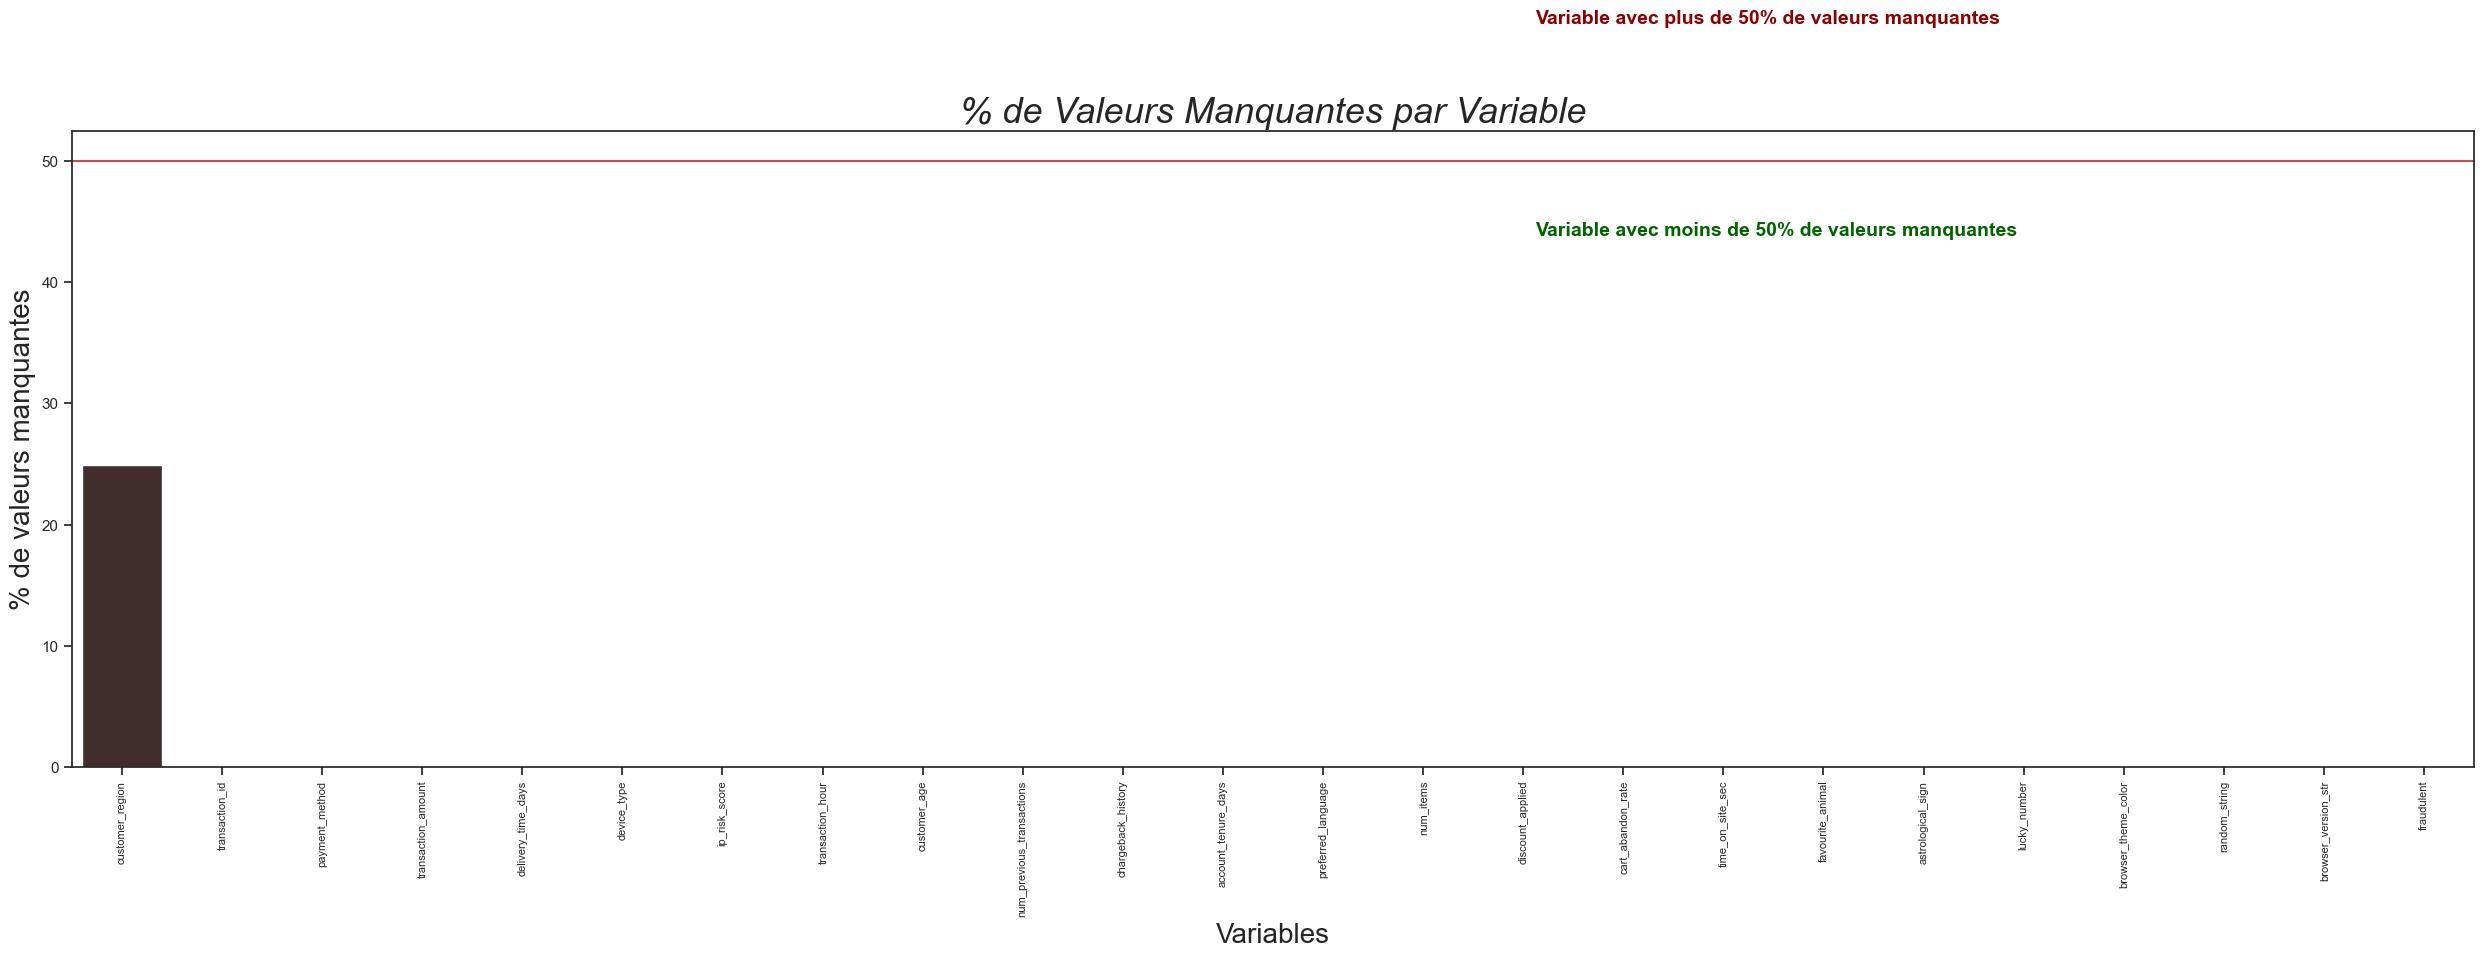

In [685]:
# Set the style for the visualization
sns.set(style='ticks', rc={'figure.figsize':(25, 10)}, palette="pink")
thresh_na = 50

# Create the plot
fig, ax = plt.subplots()
perc = (data.isnull().sum()/data.shape[0])*100
perc = perc.sort_values(ascending=False)

# Create the bar plot
sns.barplot(x=perc.index, y=perc.values, palette='pink', ax=ax)

# Add a horizontal line at the threshold
# Fixed the linestyle from '_' to '-' (valid value)
plt.axhline(y=thresh_na, color='r', linestyle='-')

# Add text annotations
# Fixed the error in data.isnull().sm() to data.isnull().sum()
plt.text(len(perc)/1.7,
         thresh_na+12.5, 
         f'Variable avec plus de {thresh_na}% de valeurs manquantes', 
         fontsize=14, weight='bold', color='darkred', ha='left', va='top')

plt.text(len(perc)/1.7, 
         thresh_na-5, 
         f'Variable avec moins de {thresh_na}% de valeurs manquantes', 
         fontsize=14, weight='bold', color='darkgreen', ha='left', va='top')

# Set titles and labels
ax.set_title('% de Valeurs Manquantes par Variable', loc="center", fontsize=26, fontstyle='italic')
ax.set_xlabel('Variables', fontsize=20)
ax.set_ylabel('% de valeurs manquantes', fontsize=20)
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()


La variable customer_region est la seule à contenir des valeurs manquantes (environ 25 % des données).  
Remplacer ces valeurs par le mode aurait faussé la distribution et introduit un biais.

La solution retenue consiste à créer une nouvelle catégorie "Unknown" pour plusieurs raisons :  
- L’absence d’information peut être significative (exemple : usage de VPN ou anonymisation).  
- Cette méthode préserve la distribution réelle des régions existantes.  
- Elle reste transparente et évite toute imputation arbitraire.

Cette approche permet de nettoyer la base tout en valorisant une information potentiellement prédictive dans le cadre de la détection de fraude.


In [688]:
data['customer_region'].fillna('Unknown', inplace = True)

# Vérifier que le remplacement a été effectué
print("Valeurs manquantes dans data après imputation:")
print(data['customer_region'].isnull().sum()) # Devrait afficher 0

print("\nCatégories uniques dans customer_region:")
print(data['customer_region'].unique()) # Devrait montrer 'Unknown' dans la liste

Valeurs manquantes dans data après imputation:
0

Catégories uniques dans customer_region:
['EU' 'Unknown' 'APAC' 'ME' 'LATAM']


##### **4.  distributions de la cible "Fraudulent"**

In [691]:
fraude = len(data.loc[data['fraudulent'] == 1,:])
legitime = len(data.loc[data['fraudulent'] == 0])
pct_fraude = fraude / (fraude + legitime)
print(f"The percentage of fraude is {pct_fraude * 100}")
pct_legitime = legitime / (fraude + legitime)
print(f"The percentage of person who is legitime is {pct_legitime * 100}")

The percentage of fraude is 7.244444444444445
The percentage of person who is legitime is 92.75555555555556


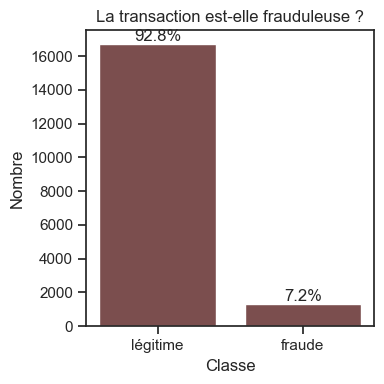

In [693]:

loan_map = {1: "fraude", 0: "légitime"}
counts = data['fraudulent'].map(loan_map).value_counts()
counts = counts.reindex(["légitime", "fraude"])
total = counts.sum()
perc = (counts / total * 100).round(1)

fig, ax = plt.subplots(figsize=(4,4))
ax.bar(counts.index, counts.values)
ax.set_title("La transaction est-elle frauduleuse ?")
ax.set_ylabel("Nombre")
ax.set_xlabel("Classe")

# Ajout des pourcentages au-dessus
for i, (v, p) in enumerate(zip(counts.values, perc.values)):
    ax.text(i, v, f"{p}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# **EDA : variables qaulitatives et quantitatives**

##### 1.   **variables qualitatives**

In [697]:
print(data.select_dtypes(exclude = [np.number]).columns.to_list())

['payment_method', 'device_type', 'customer_region', 'preferred_language', 'favourite_animal', 'astrological_sign', 'browser_theme_color', 'random_string', 'browser_version_str']


In [698]:
def graph_barre(df, var, couleur, titre, taille):
    fig, ax = plt.subplots(figsize = taille)
    
    plot_countplot(df = data,
                   col = var,
                   order = True,
                   palette = couleur,
                   ax=ax, orient = 'v',
                   size_labels = 12)
    plt.title(titre, loc = "center", fontsize = 18, fontstyle = 'italic')
    plt.show()

<h5 style="color: green;"> payement_method</h5>


In [700]:
data['payment_method'].value_counts()

payment_method
card             10714
paypal            3710
bank_transfer     1767
google_pay         912
apple_pay          897
Name: count, dtype: int64

In [701]:
couleur = {
    "card": "#1f77b4",
    "paypal": "#2ca02c",
    "bank_transfer": "#ff7f0e",
    "apple_pay": "#9467bd",
    "google_pay": "#8c564b"
}


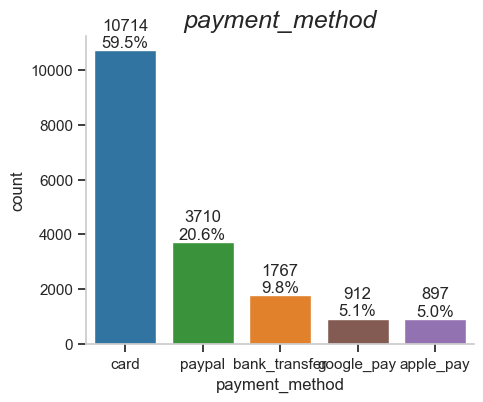

In [704]:
graph_barre(data, 'payment_method', couleur, 'payment_method', (5,4))

**commentaire** : L'analyse de la répartition des méthodes de paiement montre une forte prédominance de la carte bancaire (`card`), utilisée dans 59,5% des cas, établissant ainsi la norme comportementale. PayPal suit avec 20,6%, tandis que les autres méthodes (virement, Google/Apple Pay) sont minoritaires. L'étape suivante consistera à déterminer si le taux de fraude varie significativement entre ces catégories pour évaluer leur niveau de risque respectif.

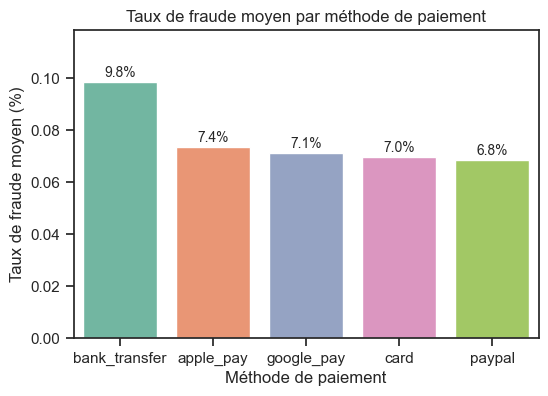

In [706]:
# Calcul du taux de fraude moyen par méthode de paiement
fraud_by_payment = data.groupby("payment_method")["fraudulent"].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
ax = sns.barplot(x=fraud_by_payment.index, y=fraud_by_payment.values, palette="Set2")

# Ajouter les pourcentages au-dessus de chaque barre
for i, value in enumerate(fraud_by_payment.values):
    plt.text(i, value + 0.001, f"{value*100:.1f}%", ha='center', va='bottom', fontsize=10)

plt.title("Taux de fraude moyen par méthode de paiement")
plt.ylabel("Taux de fraude moyen (%)")
plt.xlabel("Méthode de paiement")
plt.ylim(0, fraud_by_payment.max() + 0.02)  # un peu d’espace en haut pour les labels
plt.show()

In [709]:
# Table de contingence : nombre de fraudes (1) et non-fraudes (0) par méthode
contingency_table = pd.crosstab(data["payment_method"], data["fraudulent"])

# Test du Chi²
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi² =", round(chi2, 3))
print("p-value =", round(p, 5))


Chi² = 20.074
p-value = 0.00048


Le test du Chi² (χ² = 20.07, p = 0.00048) indique une différence significative entre les méthodes de paiement concernant la probabilité de fraude.  
Ainsi, la variable *payment_method* influence clairement le risque de fraude : certaines méthodes apparaissent plus vulnérables que d’autres.  
Cette information pourra être exploitée dans le modèle prédictif comme variable explicative importante.



<h5 style="color: green;">device_type</h5>

In [712]:
data['device_type'].value_counts()


device_type
mobile     10743
desktop     6441
tablet       816
Name: count, dtype: int64

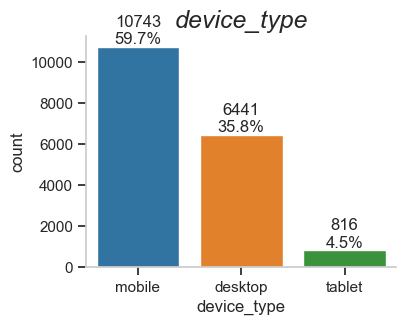

In [713]:
couleur_device = {
    "mobile":  "#1f77b4",
    "desktop": "#ff7f0e",
    "tablet":  "#2ca02c"
}

graph_barre(data, 'device_type', couleur_device, 'device_type', (4,3))



In [715]:
# Table de contingence (comptage des fraudes/non-fraudes selon le type d'appareil)
contingency_table = pd.crosstab(data["device_type"], data["fraudulent"])

# Test du Chi²
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("=== Test du Chi² pour 'device_type' vs 'fraudulent' ===")
print(contingency_table)
print(f"\nChi² = {chi2:.3f}")
print(f"p-value = {p:.5f}")
print(f"Degrés de liberté = {dof}")


=== Test du Chi² pour 'device_type' vs 'fraudulent' ===
fraudulent      0    1
device_type           
desktop      6002  439
mobile       9928  815
tablet        766   50

Chi² = 5.146
p-value = 0.07631
Degrés de liberté = 2


Le test du Chi² (χ² = 5.15, p = 0.076) indique qu’il **n’existe pas de lien statistiquement significatif** entre le type d’appareil et la fraude (p > 0.05). 


<h5 style="color: green;"> customer_region</h5>

In [718]:
data['customer_region'].value_counts()

customer_region
EU         8191
Unknown    4485
APAC       2661
LATAM      1775
ME          888
Name: count, dtype: int64

In [720]:
couleur = {"EU": "#ad7e3f",
           "Unknown": "#cbe6e2",
           "APAC" : "#f0e5c9",
           "LATAM" : "#418b85",
           "ME": "#902b5c"}

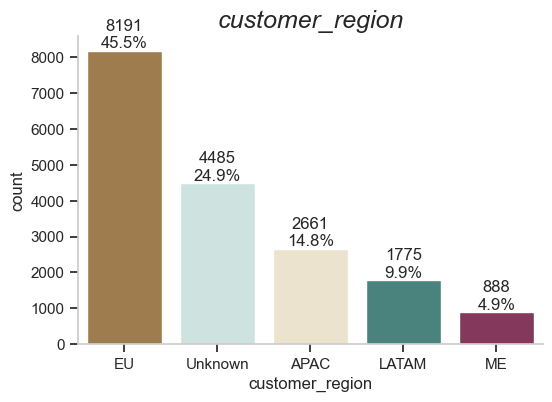

In [721]:
graph_barre(data, 'customer_region', couleur, 'customer_region', (6,4))

<h5 style="color: green;"> preferred_language</h5>

In [725]:
data['preferred_language'].value_counts()

preferred_language
en    9107
fr    2647
es    1827
de    1774
it    1409
pt    1236
Name: count, dtype: int64

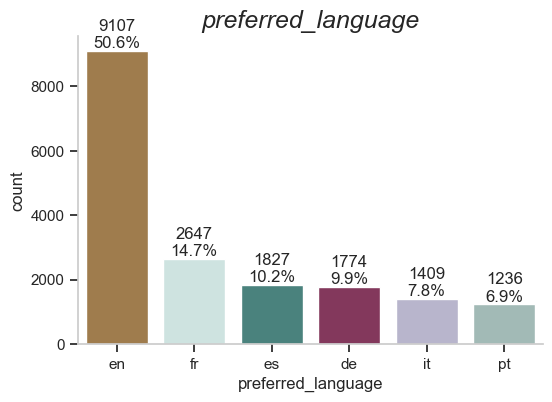

In [727]:
couleur = {"en": "#ad7e3f",
           "fr": "#cbe6e2",
           "es" : "#f0e5c9",
           "es" : "#418b85",
           "de": "#902b5c",
          "it": "#b5b1d0",
          "pt": "#9ebeb8"}
graph_barre(data, 'preferred_language', couleur, 'preferred_language', (6,4))

<h5 style="color: green;"> favourite_animal</h5>

In [730]:
data['favourite_animal'].value_counts()


favourite_animal
rabbit      3043
elephant    3032
tiger       3022
dog         3008
owl         2948
cat         2947
Name: count, dtype: int64

In [731]:
couleur = {"rabbit": "#ad7e3f",
           "elephant": "#cbe6e2",
           "tiger" : "#f0e5c9",
           "dog" : "#418b85",
           "owl": "#902b5c",
          "cat": "#b5b1d0"}

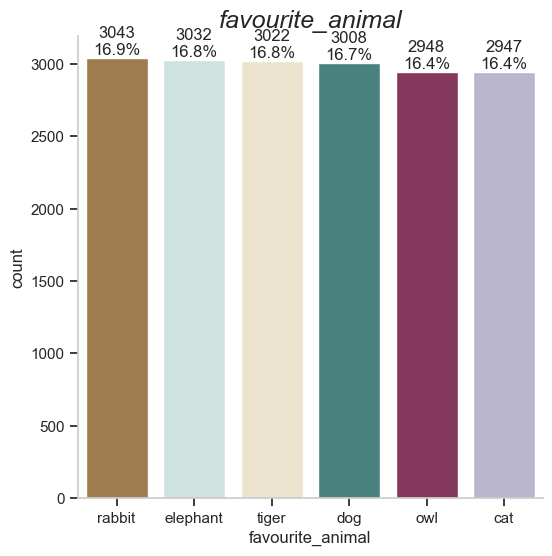

In [732]:
graph_barre(data, 'favourite_animal', couleur, 'favourite_animal', (6,6))


**commentaire :**  Pas de déséquilibre particulier → peu de signal descriptif à ce stade. favourite_animal est une variable fantaisie / bruit du jeu e-commerce (elle est listée dans le dataset, mais sans lien métier évident avec la fraude). Elle a donc forte probabilité d’être non-prédictive, voire d’introduire du bruit.

<h5 style="color: green;">astrological_sign</h5>

In [742]:
data['astrological_sign'].value_counts()

astrological_sign
Leo            1571
Pisces         1527
Cancer         1522
Libra          1514
Gemini         1507
Capricorn      1504
Aries          1490
Sagittarius    1484
Aquarius       1472
Scorpio        1472
Taurus         1469
Virgo          1468
Name: count, dtype: int64

In [744]:
couleur = {
    "Aries": "#FF4500",         # Fiery red-orange
    "Taurus": "#228B22",        # Forest green
    "Gemini": "#FFD700",        # Bright gold
    "Cancer": "#87CEFA",        # Light sky blue
    "Leo": "#FFA500",           # Orange
    "Virgo": "#8B4513",         # Saddle brown
    "Libra": "#DA70D6",         # Orchid purple
    "Scorpio": "#800000",       # Maroon
    "Sagittarius": "#9370DB",   # Medium purple
    "Capricorn": "#2F4F4F",     # Dark slate gray
    "Aquarius": "#00BFFF",      # Deep sky blue
    "Pisces": "#40E0D0"         # Turquoise
}

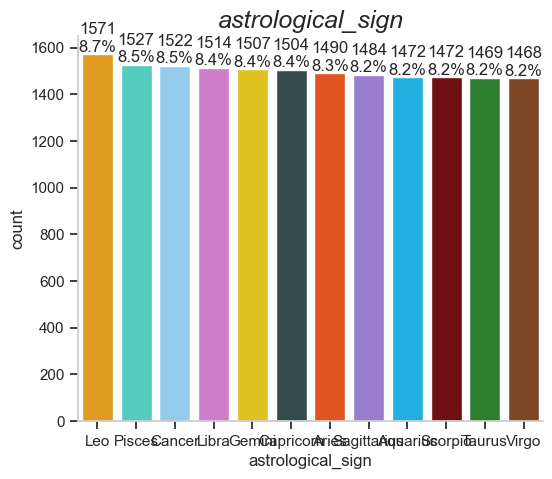

In [746]:
graph_barre(data, 'astrological_sign', couleur, 'astrological_sign', (6,5))

**commentaire :** De même, cette information est très probablement sans rapport avec le risque de fraude.

<h5 style="color: green;">browser_theme_color</h5>

In [750]:
data['browser_theme_color'].value_counts()

browser_theme_color
green     3675
light     3644
blue      3583
purple    3558
dark      3540
Name: count, dtype: int64

In [751]:
couleur = {"green": "#ad7e3f",
           "light": "#cbe6e2",
           "blue" : "#f0e5c9",
           "purple" : "#418b85",
           "dark": "#902b5c"}


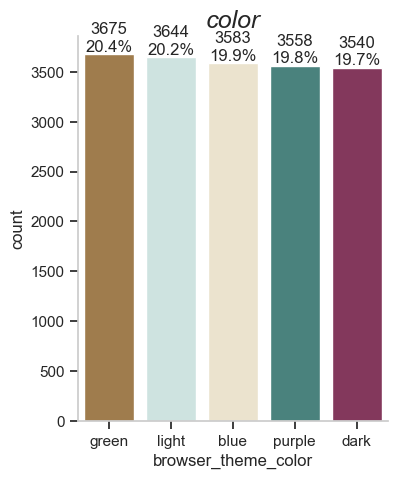

In [752]:
graph_barre(data, 'browser_theme_color', couleur, 'color', (4,5))

**commentaire :** Information purement cosmétique et non pertinente.

<h5 style="color: green;">random_string</h5>

In [757]:
data['random_string'].value_counts()

random_string
r_8713    9
r_4235    8
r_7592    8
r_2123    8
r_179     8
         ..
r_3187    1
r_4946    1
r_6785    1
r_1303    1
r_6209    1
Name: count, Length: 8358, dtype: int64

<h5 style="color: green;">browser_version_str</h5>

In [761]:
data['browser_version_str'].value_counts()

browser_version_str
light_elephant     645
green_tiger        633
blue_tiger         630
light_dog          630
dark_rabbit        623
green_rabbit       622
purple_elephant    621
green_elephant     618
purple_rabbit      612
light_cat          611
dark_tiger         610
green_owl          609
green_dog          607
purple_cat         599
blue_owl           596
blue_dog           594
blue_rabbit        594
light_rabbit       592
light_owl          591
dark_dog           590
dark_owl           587
blue_cat           587
purple_dog         587
green_cat          586
blue_elephant      582
light_tiger        575
purple_tiger       574
dark_elephant      566
purple_owl         565
dark_cat           564
Name: count, dtype: int64

**commentaire :** L'analyse de la variable `browser_version_str` révèle qu'il ne s'agit pas d'une véritable version de navigateur, mais de chaînes de caractères synthétiques (ex: `light_elephant`, `green_tiger`) réparties de manière quasi uniforme à travers l'ensemble des données. Aucun lien logique ne pouvant être établi entre ces valeurs et le risque de fraude, cette variable est considérée comme du bruit statistique. Par conséquent, elle sera **retirée du jeu de données** lors du prétraitement afin de ne pas interférer avec la performance et la pertinence du modèle.

<h5 style="color: green;"> Discount applied</h5>

In [765]:
data['discount_applied'].value_counts()

discount_applied
0    12683
1     5317
Name: count, dtype: int64

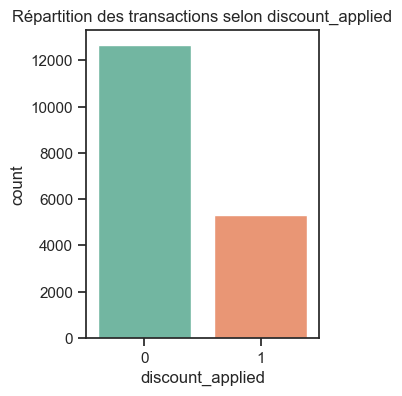

In [767]:
couleur = {"1": "#ad7e3f",
           "0": "#cbe6e2"}

plt.figure(figsize=(3,4))
sns.countplot(data=data, x="discount_applied", palette="Set2")
plt.title("Répartition des transactions selon discount_applied")
plt.show()



<h5 style="color: green;">  Chargeback history</h5>

In [770]:
data['chargeback_history'].value_counts()

chargeback_history
0    17303
1      697
Name: count, dtype: int64

In [771]:
# Définition des couleurs
couleur = {
    0: "#1f77b4",  # pas de chargeback
    1: "#d62728"   # avec chargeback
}

# Création du graphique
plt.figure(figsize=(3,4))
sns.countplot(data=data, x="chargeback_history", palette=couleur)

plt.title("Répartition des transactions selon l'historique de chargebacks", fontsize=10, pad=15)
plt.xlabel("Historique de chargebacks (0 = non, 1 = oui)")
plt.ylabel("Nombre de transactions")
plt.tight_layout()
plt.show()


ValueError: The palette dictionary is missing keys: {'0', '1'}

### 2.   **analyse bivarié : variables catégorielles**

<h3 style="color:#059669;">
Répartition des méthodes de paiement en fonction du statut de fraude (%)
</h3>



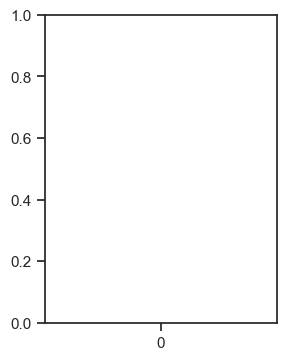

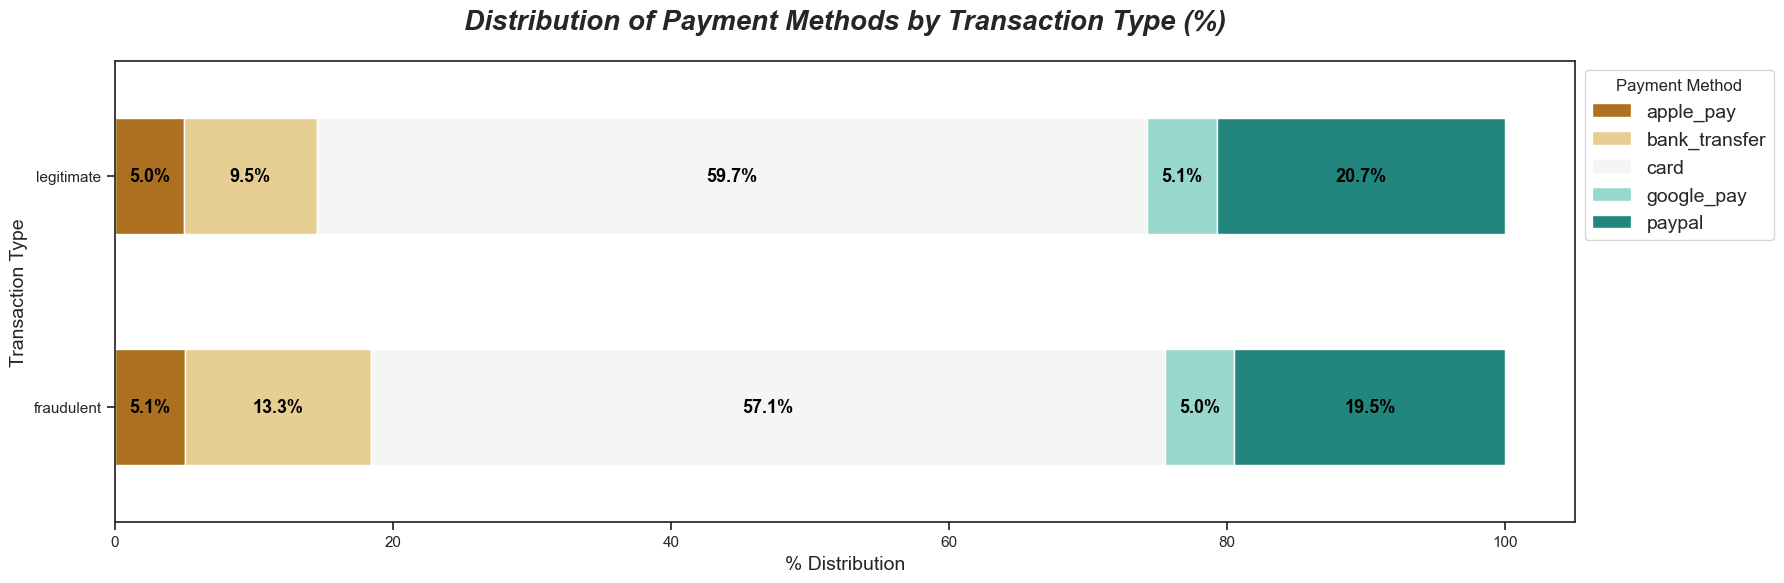

In [774]:
fraud_map = {
    1: "fraudulent",
    0: "legitimate"
}
# Tableau croisé SANS la ligne "All"
df_tab_croisee = pd.crosstab(
    data['fraudulent'].map(fraud_map),
    data['payment_method'],
    normalize='index'
) * 100

sns.set(style="ticks", rc={'figure.figsize': (18, 6)})
sns.set_palette("BrBG", len(data['payment_method'].unique()))

ax_1 = df_tab_croisee.plot.barh(stacked=True, rot=0)

for rec in ax_1.patches:
    height = rec.get_height()
    width = rec.get_width()
    if width > 1:
        ax_1.text(rec.get_x() + width / 2,
                  rec.get_y() + height / 2,
                  "{:.1f}%".format(width),
                  ha='center', va='center',
                  color='black', fontweight='bold', fontsize=13)

plt.xlabel('% Distribution', fontsize=14)
plt.ylabel('Transaction Type', fontsize=14)
plt.legend(bbox_to_anchor=(1, 1), fontsize=14, title="Payment Method")
plt.title('Distribution of Payment Methods by Transaction Type (%)',
          y=1.05, fontsize=20, fontstyle='italic', fontweight='bold')
plt.tight_layout()
plt.show()


<h3 style="color:#059669;">Taux de fraude selon la combinaison méthode de paiement / région</h3>



In [777]:
cross = data.groupby(['payment_method','customer_region'])['fraudulent'].agg(['count','mean'])
cross['lift'] = cross['mean'] / data['fraudulent'].mean()
cross.reset_index().sort_values('lift', ascending=False).head(5)


,payment_method,customer_region,count,mean,lift
18,google_pay,ME,42,0.14,1.97
6,bank_transfer,EU,789,0.11,1.54
5,bank_transfer,APAC,279,0.11,1.53
22,paypal,LATAM,367,0.10,1.39
15,google_pay,APAC,138,0.09,1.30


Les utilisateurs de Google Pay dans la région ME (Middle East) présentent le taux de fraude le plus élevé, deux fois la moyenne globale.

Les paiements par virement bancaire en Europe (EU) et en Asie-Pacifique (APAC) affichent aussi un risque supérieur à la moyenn.

Certaines combinaisons géographiques et de moyens de paiement concentrent davantage de fraudes, ce qui justifie une surveillance renforcée pour ces segments.
ts.
ents.


<h3 style="color:#059669;"> analyse de l’effet des interactions entre mode de paiement et région sur le taux de fraude</h3>


In [781]:
data['interaction_bt_eu'] = (
    ((data['payment_method'] == 'bank_transfer') & (data['customer_region'] == 'EU'))
).astype(int)

data['interaction_gp_me'] = (
    ((data['payment_method'] == 'google_pay') & (data['customer_region'] == 'ME'))
).astype(int)


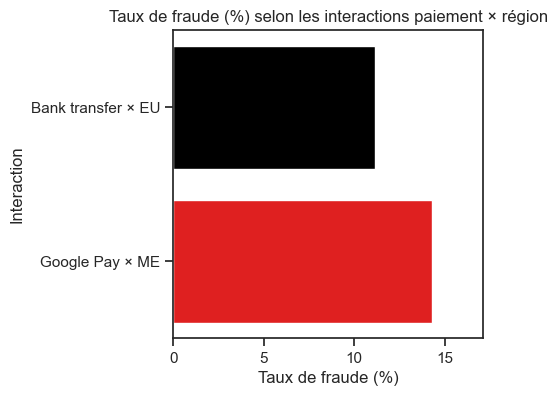

In [783]:
# Calcul du taux de fraude par modalité d'interaction
fraud_effect = pd.DataFrame({
    'interaction': ['Bank transfer × EU', 'Google Pay × ME'],
    'taux_fraude_%': [
        data.loc[data['interaction_bt_eu'] == 1, 'fraudulent'].mean() * 100,
        data.loc[data['interaction_gp_me'] == 1, 'fraudulent'].mean() * 100
    ]
})

# Couleurs personnalisées (dans l'ordre des interactions)
couleurs = ['black', 'red']

# Visualisation
plt.figure(figsize=(4,4))
sns.barplot(
    x='taux_fraude_%',
    y='interaction',
    data=fraud_effect,
    palette=couleurs
)
plt.title("Taux de fraude (%) selon les interactions paiement × région")
plt.xlabel("Taux de fraude (%)")
plt.ylabel("Interaction")
plt.xlim(0, fraud_effect['taux_fraude_%'].max() * 1.2)
plt.show()


**Analyse :** Le taux de fraude est plus élevé pour la combinaison Google Pay × Moyen-Orient (≈15 %) que pour Bank Transfer × Europe (≈11 %).  
Cela suggère que certaines interactions entre **méthode de paiement et région géographique influencent le risque de fraude,  
indiquant un effet conjoint potentiel entre les deux variables.


<h3 style="color:#d32f2f; font-weight:700;">suppression de 6 variables</h3>



In [787]:
remove = ['transaction_id', 'favourite_animal', 'astrological_sign', 'browser_theme_color', 'random_string', 'browser_version_str']
data.drop(labels = remove, axis=1, inplace=True)
data.shape

(18000, 20)

### 3.   **variables qunatitatives**

In [790]:
# Print list of numeric (quantitative) columns
print("\nQuantitative variables:")
quant_vars = data.select_dtypes(include=[np.number]).columns.to_list()
print(quant_vars)


Quantitative variables:
['transaction_amount', 'transaction_hour', 'delivery_time_days', 'ip_risk_score', 'customer_age', 'num_previous_transactions', 'chargeback_history', 'account_tenure_days', 'num_items', 'discount_applied', 'cart_abandon_rate', 'time_on_site_sec', 'lucky_number', 'fraudulent', 'interaction_bt_eu', 'interaction_gp_me']


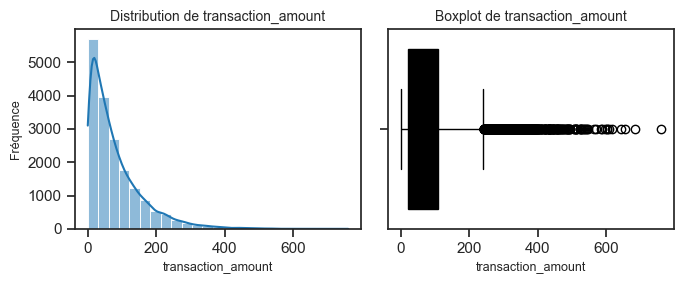

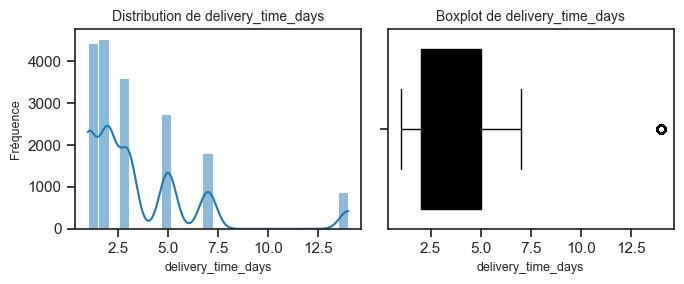

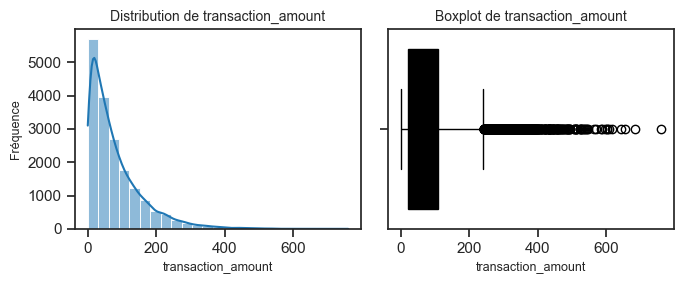

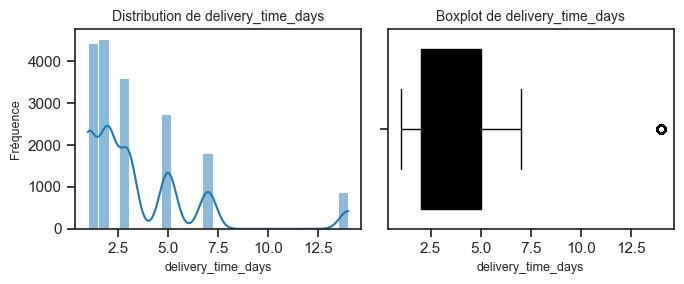

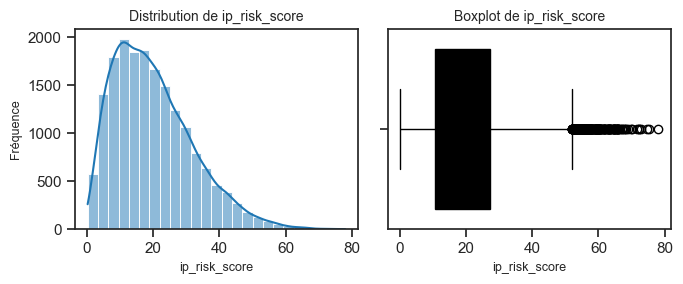

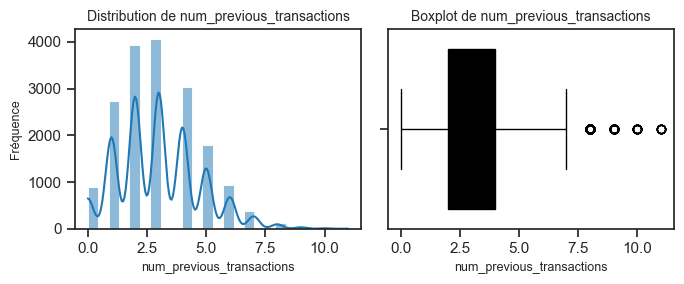

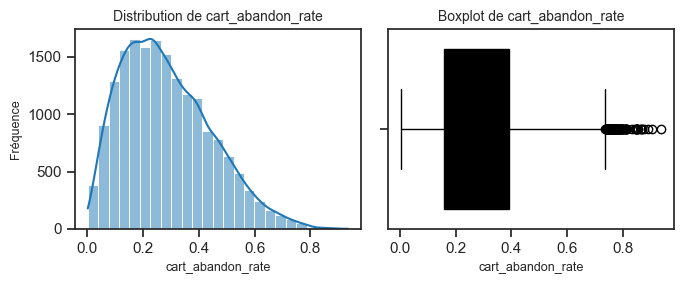

In [792]:
import matplotlib.pyplot as plt
import seaborn as sns

def hist_boxplot(df, variable, title=None):
    plt.figure(figsize=(7, 3))  # Taille plus petite

    # Histogramme
    plt.subplot(1, 2, 1)
    sns.histplot(df[variable], bins=25, kde=True, color="#1f77b4")
    plt.title(f"Distribution de {title or variable}", fontsize=10)
    plt.xlabel(variable, fontsize=9)
    plt.ylabel("Fréquence", fontsize=9)

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[variable], color="black")
    plt.title(f"Boxplot de {title or variable}", fontsize=10)
    plt.xlabel(variable, fontsize=9)

    plt.tight_layout()
    plt.show()

# Tes variables continues (avec doublons gardés si tu veux)
var_continues = [
    'transaction_amount', 'delivery_time_days', 'transaction_amount',
    'delivery_time_days', 'ip_risk_score', 'num_previous_transactions', 'cart_abandon_rate'
]

# Boucle d'affichage
for var in var_continues:
    hist_boxplot(data, var, var)


commentaire:
- **transaction_amount** : La plupart des montants sont faibles (< 100 €) avec quelques valeurs très élevées.  
- **delivery_time_days** : Les livraisons se font majoritairement en 2 à 5 jours, avec quelques délais exceptionnels (≈ 14 jours).  
- **ip_risk_score** : La majorité des transactions ont un score IP faible, mais certaines valeurs élevées signalent des risques potentiels.  
- **num_previous_transactions** : Les clients ont souvent entre 2 et 5 transactions, quelques-uns dépassent 8.  
- **cart_abandon_rate** : Le taux d’abandon est globalement faible à modéré (0,1–0,4), avec quelques cas extrêmes.  


<h5 style="color: green;">  Tableau statistiques descriptives </h5>

In [795]:
# Get list of quantitative variables
quant_vars = data.select_dtypes(include=[np.number]).columns.to_list()

# Remove the three variables you want to exclude
exclude_vars = ['chargeback_history', 'transaction_id', 'discount_applied']
quant_vars = [var for var in quant_vars if var not in exclude_vars]

# Calculate descriptive statistics and transpose for better readability
desc_stats = data[quant_vars].describe().T
desc_stats

,count,mean,std,min,25%,50%,75%,max
transaction_amount,"18,000.00",79.32,79.11,0.00,22.85,54.92,110.32,759.66
transaction_hour,"18,000.00",11.56,6.98,0.00,5.00,12.00,18.00,23.00
delivery_time_days,"18,000.00",3.49,3.01,1.00,2.00,3.00,5.00,14.00
ip_risk_score,"18,000.00",19.98,11.99,0.20,10.70,18.10,27.20,78.00
customer_age,"18,000.00",48.63,17.83,18.00,33.00,49.00,64.00,79.00
num_previous_transactions,"18,000.00",3.00,1.73,0.00,2.00,3.00,4.00,11.00
account_tenure_days,"18,000.00","2,479.95","1,433.90",1.00,"1,237.75","2,461.00","3,709.00","4,999.00"
num_items,"18,000.00",4.98,2.58,1.00,3.00,5.00,7.00,9.00
cart_abandon_rate,"18,000.00",0.28,0.16,0.00,0.16,0.26,0.39,0.94
time_on_site_sec,"18,000.00",187.13,108.93,0.00,102.00,179.00,261.00,718.00


**Commentaire :**

La variable fraudulent a une moyenne de 0.07, ce qui montre que le jeu de données est déséquilibré : les transactions légitimes sont beaucoup plus nombreuses que les fraudes. Cela influencera l’évaluation des modèles, car la simple précision ne sera pas une métrique fiable.

Pour transaction_amount, la médiane est de 54.92 €, et la moyenne est plus élevée, ce qui suggère la présence de quelques montants très élevés qui tirent la moyenne vers le haut.

Concernant ip_risk_score, 75 % des transactions ont un score inférieur à 27.20, ce qui indique que la plupart des transactions proviennent d’adresses IP peu risquées. Cependant, certaines atteignent 78.00, correspondant à des cas de risque très élevé.

Pour account_tenure_days, l’ancienneté moyenne d’un compte est de 2480 jours (environ 6,8 ans). Une transaction provenant d’un compte très récent (valeur proche de 1) est donc particulièrement suspecte.

Enfin, chargeback_history montre que 4 % des transactions sont associées à un compte ayant déjà contesté un paiement. C’est un événement rare, mais probablement un signal fort de comportement frauduleux.



<h5 style="color: green;">  matrice de corrélation - Va Quantitatives </h5>

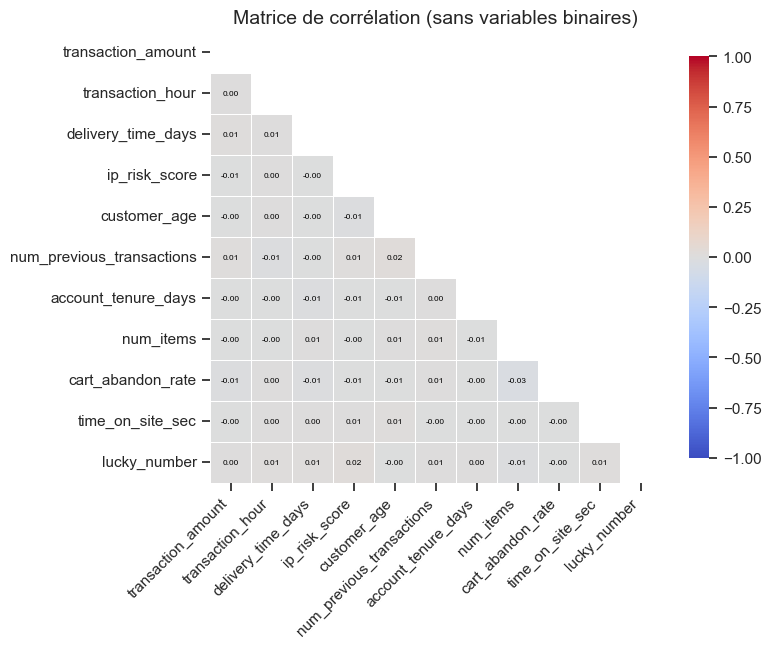

In [800]:
# 1 Sélection des variables numériques uniquement
num_data = data.select_dtypes(['number'])

# 2 Suppression des variables binaires (0/1)
# On garde uniquement les colonnes ayant plus de 2 valeurs uniques
num_data_no_binary = num_data.loc[:, num_data.nunique() > 2]

# 3Calcul de la matrice de corrélation (Pearson)
corr = num_data_no_binary.corr(method='pearson')

#  Masque pour le triangle supérieur (facultatif)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 5Visualisation du heatmap
plt.figure(figsize=(8,8))
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={'shrink': .6},
    annot_kws={'size': 6, 'color': 'black'}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Matrice de corrélation (sans variables binaires)', fontsize=14)
plt.tight_layout()
plt.show()

<h5 style="color: green;">Analyse bivariée des variables quantitatives selon le statut de fraude</h5>

In [803]:
def plot_fraud_scatterplot(df, num_var1, num_var2, target="fraudulent"):
    plt.figure(figsize=(4,3))
    sns.scatterplot(
        x=num_var1, y=num_var2, 
        hue=target, data=df, alpha=0.5, palette={0:"green", 1:"red"}
    )
    sns.regplot(x=num_var1, y=num_var2, data=df, scatter=False, color="black", line_kws={"lw":1})
    
    plt.title(f"{num_var1} vs {num_var2} (fraude en rouge)")
    plt.xlabel(num_var1)
    plt.ylabel(num_var2)
    plt.legend(title="Fraude", labels=["Non fraude","Fraude"])
    plt.show()

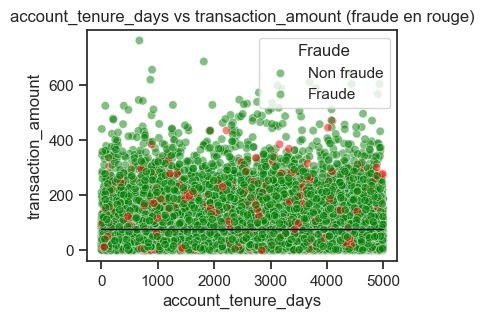

In [805]:
# Analyse 2 : fraude par "nouveau compte"
plot_fraud_scatterplot(data, num_var1="account_tenure_days", num_var2="transaction_amount")


**Analyse :**  Les transactions frauduleuses (en rouge) sont réparties de manière homogène parmi les transactions légitimes, sans concentration particulière selon l’ancienneté du compte.  
La droite de régression, quasiment horizontale, indique l’absence de relation entre la durée de vie du compte et le montant des transactions, suggérant que la fraude n’est pas liée à l’âge du compte.


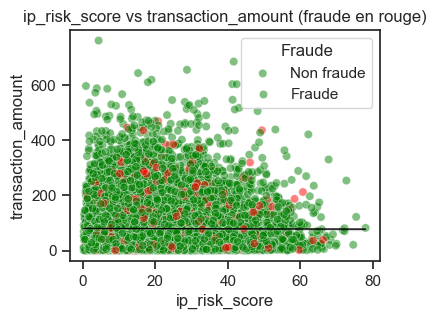

In [807]:
# Analyse 3 : fraude avec score IP élevé + gros montants
plot_fraud_scatterplot(data, num_var1="ip_risk_score", num_var2="transaction_amount")


**Analyse :**  Les fraudes (en rouge) se répartissent de façon diffuse parmi les transactions normales, sans schéma clair reliant le score IP et le montant.  

La droite de régression horizontale montre l’absence de relation significative entre le score de risque IP et le montant des transactions, indiquant que des scores IP élevés ne sont pas systématiquement associés à des montants plus importants.


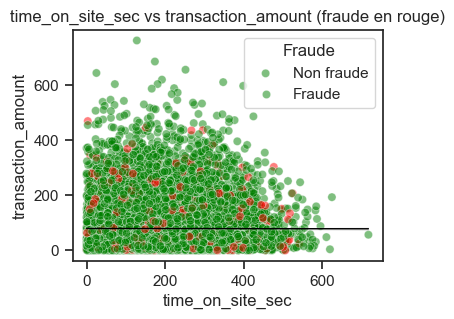

In [809]:
plot_fraud_scatterplot(data, num_var1="time_on_site_sec", num_var2="transaction_amount")


**Analyse :** Les transactions frauduleuses sont dispersées parmi les transactions légitimes, sans zone spécifique ni tendance marquée.  
La droite de régression horizontale indique l’absence de relation entre le temps passé sur le site et le montant des transactions, suggérant que la rapidité d’achat n’est pas un indicateur de fraude.


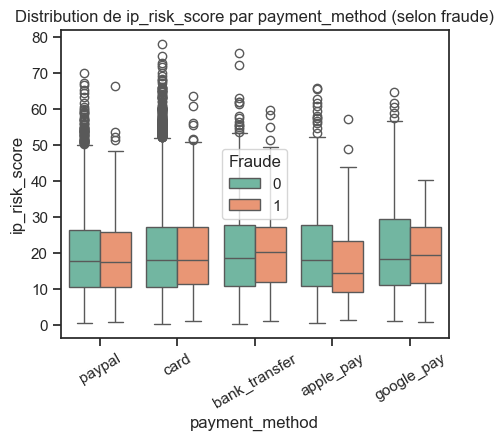

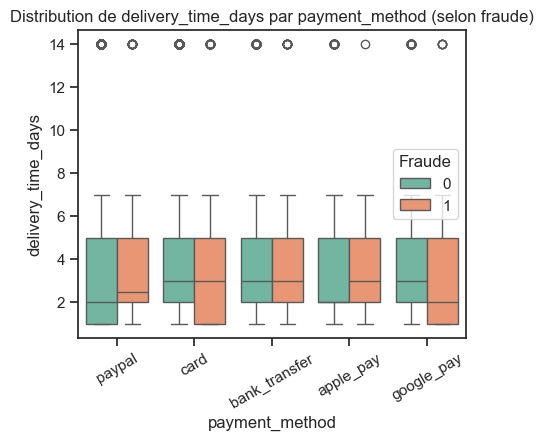

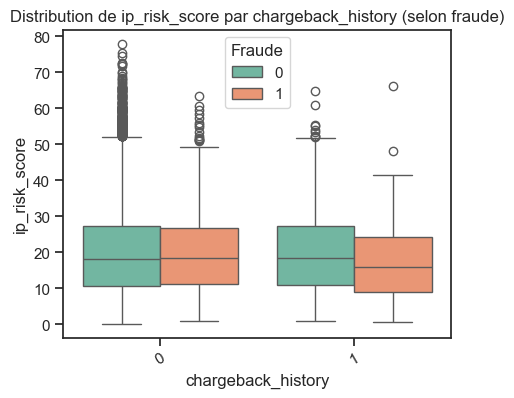

In [813]:
def plot_fraud_boxplot(df, cat_var, num_var, target="fraudulent"):

    plt.figure(figsize=(5,4))
    sns.boxplot(x=cat_var, y=num_var, hue=target, data=df, palette="Set2")
    plt.title(f"Distribution de {num_var} par {cat_var} (selon fraude)")
    plt.xticks(rotation=30)
    plt.xlabel(cat_var)
    plt.ylabel(num_var)
    plt.legend(title="Fraude")
    plt.show()

plot_fraud_boxplot(data, "payment_method", "ip_risk_score")
plot_fraud_boxplot(data, "payment_method", "delivery_time_days")
plot_fraud_boxplot(data, "chargeback_history", "ip_risk_score")


**commentaire** : 
Les médianes et les étendues interquartiles sont proches entre fraudes et non-fraudes, quel que soit le mode de paiement.
le score IP reste stable quel que soit le mode de paiement, sans différence notable liée à la fraude

Les médianes du délai de livraison sont proches entre fraudes et non-fraudes pour l’ensemble des modes de paiement.
Les distributions présentent une dispersion modérée et quelques outliers élevés (livraisons > 10 jours), sans différence structurelle visible.

Les médianes et la dispersion du score IP sont similaires entre les clients avec ou sans historique de rétrofacturation. La présence de quelques outliers élevés ne modifie pas cette tendance, indiquant l’absence de lien clair entre le score IP et l’historique de chargebacks.

<h5 style="color: green;">  convertir delivery time days en variables catégorialles  </h5>

In [817]:
# Transformation de la variable delivery time days en variable qualitative
conditions = [
    data['delivery_time_days'] <= 2,
    (data['delivery_time_days'] > 2) & (data['delivery_time_days'] <= 5),
    data['delivery_time_days'] > 5]
choices = ['Express', 'Standard', 'Economy']
data['delivery_speed'] = np.select(conditions, choices, default='Unknown')

data[['delivery_time_days', 'delivery_speed']].head(3)

,delivery_time_days,delivery_speed
0,3,Standard
1,3,Standard
2,3,Standard


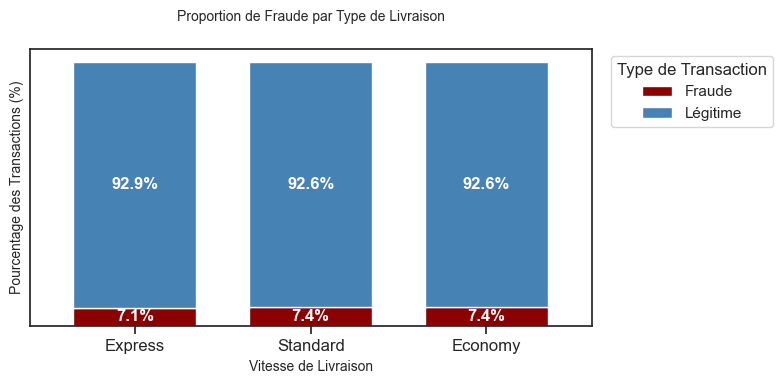

In [820]:
# On groupe par 'delivery_speed' et on calcule le taux de fraude
fraud_percentage = data.groupby('delivery_speed')['fraudulent'].mean() * 100

# On prépare un DataFrame pour le graphique
plot_data = pd.DataFrame({
    'Fraude': fraud_percentage,
    'Légitime': 100 - fraud_percentage})

# Trier les données pour un affichage plus logique (Express, Standard, Economy)
plot_data = plot_data.reindex(['Express', 'Standard', 'Economy'])

# --- CRÉATION DU GRAPHIQUE 100% EMPILÉ ---
sns.set(style="ticks")
ax = plot_data.plot(
    kind='bar', 
    stacked=True, 
    color={'Légitime': 'steelblue', 'Fraude': 'darkred'},
    figsize=(8, 4),
    width=0.7)

# --- AJOUT DES POURCENTAGES SUR LES BARRES ---
for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%.1f%%', color='white', weight='bold', fontsize=12)

# --- AMÉLIORATION DE L'ESTHÉTIQUE ---
ax.set_title("Proportion de Fraude par Type de Livraison", fontsize=10, pad=20)
ax.set_xlabel("Vitesse de Livraison", fontsize=10)
ax.set_ylabel('Pourcentage des Transactions (%)', fontsize=10)
plt.xticks(rotation=0, fontsize=12)
plt.yticks([])

# Placer la légende à l'extérieur
ax.legend(title='Type de Transaction', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


<h5 style="color: green;">  convertir  customer_age en variables catégorialles  </h5>

In [823]:
# Define age bins and labels
age_bins = [17, 25, 40, 60, np.inf]
age_labels = ['Jeune Adulte', 'Adulte', 'Senior', 'Très Senior']

# Add the new categorical variable to your existing dataframe
data['age_group'] = pd.cut(data['customer_age'], bins=age_bins, labels=age_labels, right=False)

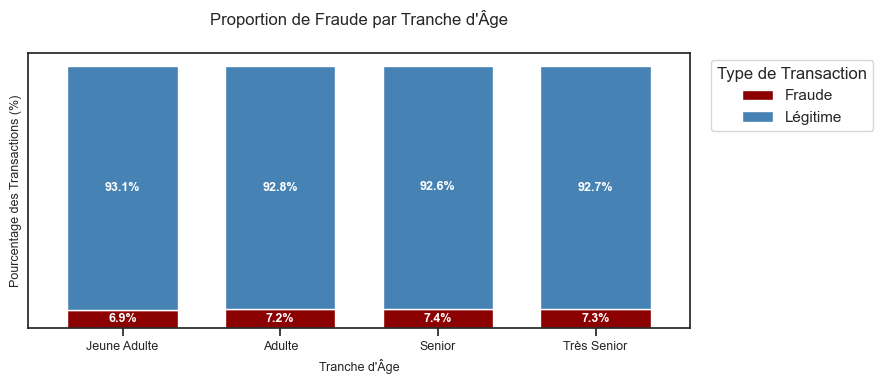

In [825]:
fraud_percentage = data.groupby('age_group')['fraudulent'].mean() * 100
fraud_percentage = fraud_percentage.sort_index() # On trie pour avoir un ordre logique (18-25, 26-40, etc.)

# On prépare un DataFrame spécialement pour le graphique, avec les pourcentages de Fraude et de Légitime.
plot_data = pd.DataFrame({
    'Fraude': fraud_percentage,
    'Légitime': 100 - fraud_percentage})

sns.set(style="ticks")
ax = plot_data.plot(
    kind='bar', 
    stacked=True, 
    color={'Légitime': 'steelblue', 'Fraude': 'darkred'},
    figsize=(9, 4),
    width=0.7)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%.1f%%', color='white', weight='bold', fontsize=9)

# --- ÉTAPE 4 : AMÉLIORATION DE L'ESTHÉTIQUE DU GRAPHIQUE ---
ax.set_title("Proportion de Fraude par Tranche d'Âge", fontsize=12, pad=20)
ax.set_xlabel("Tranche d'Âge", fontsize=9)
ax.set_ylabel('Pourcentage des Transactions (%)', fontsize=9)
plt.xticks(rotation=0, fontsize=9) # Mettre les étiquettes de l'axe X à l'horizontale
plt.yticks([]) # Cacher l'axe Y, car les pourcentages sont déjà affichés sur les barres

# Placer la légende à l'extérieur du graphique pour ne pas le surcharger
ax.legend(title='Type de Transaction', bbox_to_anchor=(1.02, 1), loc='upper left')

# Ajuster le layout pour s'assurer que tout est visible
plt.tight_layout()
plt.show()

<h5 style="color: green;">  num_previous_transactions days en variables catégorialles  </h5>

In [828]:
seuil_nouveau_client = 1

# colonne 'is_new_customer'
data['is_new_customer'] = (data['num_previous_transactions'] <= seuil_nouveau_client).astype(int)
data[['num_previous_transactions', 'is_new_customer']].head(3)


,num_previous_transactions,is_new_customer
0,3,0
1,1,1
2,3,0


<h5 style="color: green;">  Analyse de la dépendance entre les variables catégorielles et le statut de fraude (Test du χ²) </h5>

In [831]:
target = "fraudulent"

# 1) Catégorielles "texte" OU "category"
categorical_features = data.select_dtypes(include=["object", "category"]).columns.tolist()

# 2) Binaires (0/1) détectées automatiquement (hors cible)
binary_features = [
    c for c in data.columns
    if c != target
    and data[c].dropna().isin([0, 1]).all()
    and data[c].nunique(dropna=True) <= 2
]

# 3) Numériques (en excluant les binaires et la cible)
numeric_features = (
    data.select_dtypes(include=["number"]).columns
    .difference(binary_features + [target])
    .tolist()
)

print("Catégorielles (object/category):", categorical_features)
print("Binaires (0/1):", binary_features)



Catégorielles (object/category): ['payment_method', 'device_type', 'customer_region', 'preferred_language', 'delivery_speed', 'age_group']
Binaires (0/1): ['chargeback_history', 'discount_applied', 'interaction_bt_eu', 'interaction_gp_me', 'is_new_customer']


In [833]:
categorical_features = [  'payment_method', 'device_type', 'customer_region', 'preferred_language', 'delivery_speed', 'age_group','chargeback_history','discount_applied','is_new_customer','interaction_bt_eu','interaction_gp_me']
y = data['fraudulent']

chi_ls = []

for feature in categorical_features:
    
    # create contingency table
    c = pd.crosstab(y, data[feature])
    
    # chi_test
    p_value = chi2_contingency(c)[1]
    chi_ls.append(p_value)

                    p_value
interaction_bt_eu     0.000
chargeback_history    0.000
payment_method        0.000
discount_applied      0.029
device_type           0.076
interaction_gp_me     0.143
is_new_customer       0.659
delivery_speed        0.665
customer_region       0.828
age_group             0.862
preferred_language    0.985


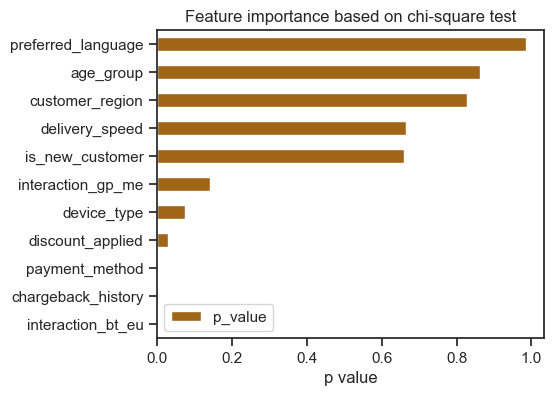

In [835]:

sns.set(style="ticks", rc={'figure.figsize': (5, 4)}, palette="BrBG")

df_pvalue = pd.DataFrame(chi_ls, index= categorical_features, columns=['p_value']).sort_values(by='p_value', ascending=True)

pd.set_option('display.float_format', '{:,.3f}'.format)
print(df_pvalue)

df_pvalue.plot.barh()
plt.xlabel('p value')
plt.title('Feature importance based on chi-square test')
plt.show()

**Analyse :**  
Les p-values montrent que :
- Les variables `interaction_bt_eu`, `chargeback_history`, `payment_method` présentent des liens statistiquement significatifs avec la fraude (p-value < 0.05).  
  Cela indique qu’elles influencent probablement la probabilité de fraude.
- Les autres variables, telles que `preferred_language`, `customer_region`, `age_group` ou `is_new_customer`, ont des p-values élevées (> 0.05), suggérant aucune relation notable avec la fraude.

les interactions entre virement bancaire et région européenne, l’historique de rétrofacturation, ainsi que le mode de paiement sont les facteurs catégoriels les plus associés à la fraude.  


### 4. **Encodage**

In [839]:

categorical_features = [
    'payment_method', 'device_type', 'customer_region',
    'preferred_language', 'delivery_speed', 'age_group'
]

binary_features = [
    'chargeback_history', 'discount_applied',
    'interaction_bt_eu', 'interaction_gp_me', 'is_new_customer'
]

# Étape 3 : Encodage des variables catégorielles avec One-Hot Encoding
# (les binaires sont déjà 0/1, donc on les garde telles quelles)
data_encoded = pd.get_dummies(
    data,
    columns=categorical_features,  # seulement les variables catégorielles
    drop_first=False,              # garder toutes les modalités (éviter perte d'information)
    dtype=int
)

print(f"Dimensions avant encodage : {data.shape}")
print(f"Dimensions après encodage : {data_encoded.shape}")
#  Aperçu du DataFrame final
display(data_encoded.head())


Dimensions avant encodage : (18000, 23)
Dimensions après encodage : (18000, 43)


,transaction_amount,transaction_hour,delivery_time_days,ip_risk_score,customer_age,num_previous_transactions,chargeback_history,account_tenure_days,num_items,discount_applied,...,preferred_language_fr,preferred_language_it,preferred_language_pt,delivery_speed_Economy,delivery_speed_Express,delivery_speed_Standard,age_group_Jeune Adulte,age_group_Adulte,age_group_Senior,age_group_Très Senior
0,37.540,7,3,40.500,19,3,0,4660,4,1,...,0,0,1,0,0,1,1,0,0,0
1,240.810,11,3,27.000,51,1,1,2188,3,1,...,0,0,0,0,0,1,0,0,1,0
2,105.340,20,3,30.500,22,3,0,521,4,0,...,0,0,0,0,0,1,1,0,0,0
3,73.040,3,2,22.700,71,1,0,2895,6,0,...,0,0,1,0,1,0,0,0,0,1
4,13.570,20,1,7.700,24,3,0,4535,8,1,...,0,1,0,0,1,0,1,0,0,0


##### distribution des variables catégorielles 

In [842]:
# 1. Définir votre liste de variables catégorielles
categorical_features = [
    'payment_method', 
    'device_type', 
    'customer_region', 
    'preferred_language', 
    'delivery_speed', 
    'age_group',
    'chargeback_history',
    'discount_applied',
    'is_new_customer',
    'interaction_bt_eu',
    'interaction_gp_me'
]

df_for_plotting = data[categorical_features].astype(str)


# 2. Appeler la fonction avec le DataFrame temporaire et propre
sns.set(style="ticks")

plot_multiple_countplots(
    df=df_for_plotting, # Utiliser le DataFrame temporaire
    col_list=categorical_features,
    n_cols=3,
    orient='h',
    palette="BrBG",
    size_labels=10,
    size_title=14
)

<p style="text-align:center; font-size:2.8em; color:#9EBEB8; line-height:4rem; font-style:italic; font-weight:700;">
   Partie II : Sélection des variables
</p>
>


# Traitement des variables catégorielles 

In [846]:
target = "fraudulent"

# 1) Catégorielles "texte" OU "category"
categorical_features = data.select_dtypes(include=["object", "category"]).columns.tolist()

# 2) Binaires (0/1) détectées automatiquement (hors cible)
binary_features = [
    c for c in data.columns
    if c != target
    and data[c].dropna().isin([0, 1]).all()
    and data[c].nunique(dropna=True) <= 2
]

# 3) Numériques (en excluant les binaires et la cible)
numeric_features = (
    data.select_dtypes(include=["number"]).columns
    .difference(binary_features + [target])
    .tolist()
)

print("Catégorielles (object/category):", categorical_features)
print("Binaires (0/1):", binary_features)

Catégorielles (object/category): ['payment_method', 'device_type', 'customer_region', 'preferred_language', 'delivery_speed', 'age_group']
Binaires (0/1): ['chargeback_history', 'discount_applied', 'interaction_bt_eu', 'interaction_gp_me', 'is_new_customer']


In [848]:
from sklearn.model_selection import train_test_split

X = data_encoded.drop(columns='fraudulent')
y = data_encoded['fraudulent']

x_train, x_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.4, random_state=1)

# Split the remaining observations into validation and test
x_val, x_test, y_val, y_test = train_test_split(x_val_test, y_val_test, test_size=0.5, random_state=1) 

In [850]:
print("y_train - TARGET")
print(pd.DataFrame({
    "COUNT": y_train.value_counts(),
    "RATIO": y_train.value_counts() / len(y_train) * 100}))

y_train - TARGET
            COUNT  RATIO
fraudulent              
0            9995 92.546
1             805  7.454


In [852]:
print("y_valid - TARGET")
print(pd.DataFrame({
    "COUNT": y_val_test.value_counts(),
    "RATIO": y_val_test.value_counts() / len(y_val_test) * 100}))

y_valid - TARGET
            COUNT  RATIO
fraudulent              
0            6701 93.069
1             499  6.931


## Standardisation des Variables explicatives

La standardisation consiste à redimensionner les variables numériques pour qu’elles soient comparables sur une échelle commune. Elle a pour but de ramener la moyenne μ à 0 et l’écart-type σ à 1.

**Pourquoi ?** Travailler avec des données d’échelles variables peut constituer un problème dans l’analyse en ce sens qu’une variable numérique dont la plage de valeurs est comprise entre 0 et 10000 sera plus pesante dans l’analyse qu’une variable dont les valeurs sont comprises entre 0 et 1 ce qui causerait un problème de biais par la suite.

**Comment ?** Il est important de remettre les cas d’usage en contexte, car en pratique il ne suffit pas d’appliquer à la standardisation à toutes les données du Dataset, pour la simple raison qu‘il n’est pas possible d’appliquer cette même transformation à un échantillon de test, ou à des données nouvelles.

Il est possible évidemment de centrer et réduire n’importe quel échantillon de la même manière, mais avec une moyenne et un écart type qui seront différents de ceux utilisés sur l’ensemble d’entraînement

Les résultats obtenus ne seraient pas une juste représentation de la performance du modèle dans son ensemble, lorsqu’il sera appliqué à de nouvelles données.

Donc, plutôt que d’appliquer directement la fonction de standardisation, il est préférable d’utiliser une fonctionnalité de Scikit-Learn appelée Transformer API, qui permettra d’ajuster (fit) une étape de preprocessing en utilisant les données d’entraînement.

Ainsi lorsque la standardisation, par exemple, sera appliquée à d’autres échantillons, elle utilisera les mêmes moyennes et écart-types sauvegardés.

Pour créer cette étape de preprocessing ‘ajustée’ il suffit d’utiliser la fonction StandardScaler puis de l’ajuster grâce aux données d’entraînement. Enfin pour l’appliquer à un tableau de données par la suite il faudra simplement lui appliquer scaler.transform().

In [855]:
numeric_features_to_scale = [
    'transaction_amount', 'transaction_hour', 'delivery_time_days',
    'ip_risk_score', 'customer_age', 'num_previous_transactions',
    'account_tenure_days', 'num_items', 'cart_abandon_rate',
    'time_on_site_sec'
]


scaler = StandardScaler()
X_train_scaled = x_train.copy()
X_test_scaled = x_test.copy()

print("--- Démarrage de la Mise à l'Échelle (StandardScaler) ---")

X_train_scaled[numeric_features_to_scale] = scaler.fit_transform(x_train[numeric_features_to_scale])

X_test_scaled[numeric_features_to_scale] = scaler.transform(x_test[numeric_features_to_scale])

--- Démarrage de la Mise à l'Échelle (StandardScaler) ---




<h3 style="color: green;">  Step Forward Feature Selection </35>

La sélection forward consiste à construire des modèles en ajoutant une variable à la fois, selon leur contribution à la performance du modèle.  
On commence avec la variable la plus prédictive, puis on teste successivement les combinaisons possibles en ajoutant de nouvelles variables jusqu’à ce qu’un critère d’arrêt soit atteint (par exemple, plus d’amélioration du score ROC-AUC ou R²).

Cette méthode, appelée "sélection pas à pas", est gloutonne et peut devenir coûteuse en calcul lorsque le nombre de variables est important.  
La bibliothèque **mlxtend** de Python permet d’automatiser cette procédure à l’aide de critères d’arrêt paramétrables (nombre de variables à retenir ou stagnation des performances).


--- Démarrage de la Sélection Séquentielle (SFS) avec RandomForest ---


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:   11.5s
[Parallel(n_jobs=-2)]: Done  35 out of  42 | elapsed:   17.9s remaining:    3.5s
[Parallel(n_jobs=-2)]: Done  42 out of  42 | elapsed:   18.1s finished

[2025-10-06 20:26:32] Features: 1/42 -- score: 0.5326010831502708[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-2)]: Done  33 out of  41 | elapsed:   12.1s remaining:    2.9s
[Parallel(n_jobs=-2)]: Done  41 out of  41 | elapsed:   12.3s finished

[2025-10-06 20:26:44] Features: 2/42 -- score: 0.5368774449336469[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-2)]: Done  32 out of  40 | elapsed:   11.3s remaining:    2.7s
[Parallel(n_jobs=-2)]: Done  40 out of  40 | elapsed:   11.4s fini


--- Sélection SFS Terminée ---

Le score optimal (AUC) est : 0.5568
Nombre optimal de variables : 12
Liste des meilleures variables sélectionnées :
['chargeback_history', 'num_items', 'interaction_bt_eu', 'interaction_gp_me', 'payment_method_bank_transfer', 'payment_method_google_pay', 'device_type_desktop', 'device_type_mobile', 'device_type_tablet', 'customer_region_APAC', 'customer_region_ME', 'preferred_language_pt']

Historique de la performance :


,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
1,"(8,)","[0.5142975214315232, 0.534107115669636, 0.5266...",0.533,"(num_items,)",0.032,0.025,0.012
2,"(8, 13)","[0.5166977898887332, 0.5471011903467262, 0.531...",0.537,"(num_items, interaction_bt_eu)",0.027,0.021,0.011
3,"(8, 13, 21)","[0.5425616534975564, 0.5579559966318564, 0.521...",0.540,"(num_items, interaction_bt_eu, device_type_des...",0.018,0.014,0.007
4,"(8, 13, 17, 21)","[0.5432017250861456, 0.5864453966113491, 0.543...",0.551,"(num_items, interaction_bt_eu, payment_method_...",0.025,0.019,0.010
5,"(8, 13, 17, 21, 24)","[0.5488722622180655, 0.5712250535205492, 0.552...",0.554,"(num_items, interaction_bt_eu, payment_method_...",0.014,0.011,0.005
6,"(8, 13, 17, 21, 24, 34)","[0.5393923669909488, 0.5775667336773979, 0.541...",0.555,"(num_items, interaction_bt_eu, payment_method_...",0.022,0.017,0.009
7,"(8, 13, 14, 17, 21, 24, 34)","[0.5450815469846724, 0.5766237155845002, 0.539...",0.556,"(num_items, interaction_bt_eu, interaction_gp_...",0.021,0.017,0.008
8,"(8, 13, 14, 17, 21, 24, 27, 34)","[0.5423783320231544, 0.5810731452682862, 0.544...",0.555,"(num_items, interaction_bt_eu, interaction_gp_...",0.020,0.016,0.008
9,"(6, 8, 13, 14, 17, 21, 24, 27, 34)","[0.5344815264775244, 0.5822756098546169, 0.546...",0.554,"(chargeback_history, num_items, interaction_bt...",0.023,0.018,0.009
10,"(6, 8, 13, 14, 17, 21, 22, 24, 27, 34)","[0.5491270479960477, 0.5756744832043351, 0.542...",0.556,"(chargeback_history, num_items, interaction_bt...",0.020,0.015,0.008


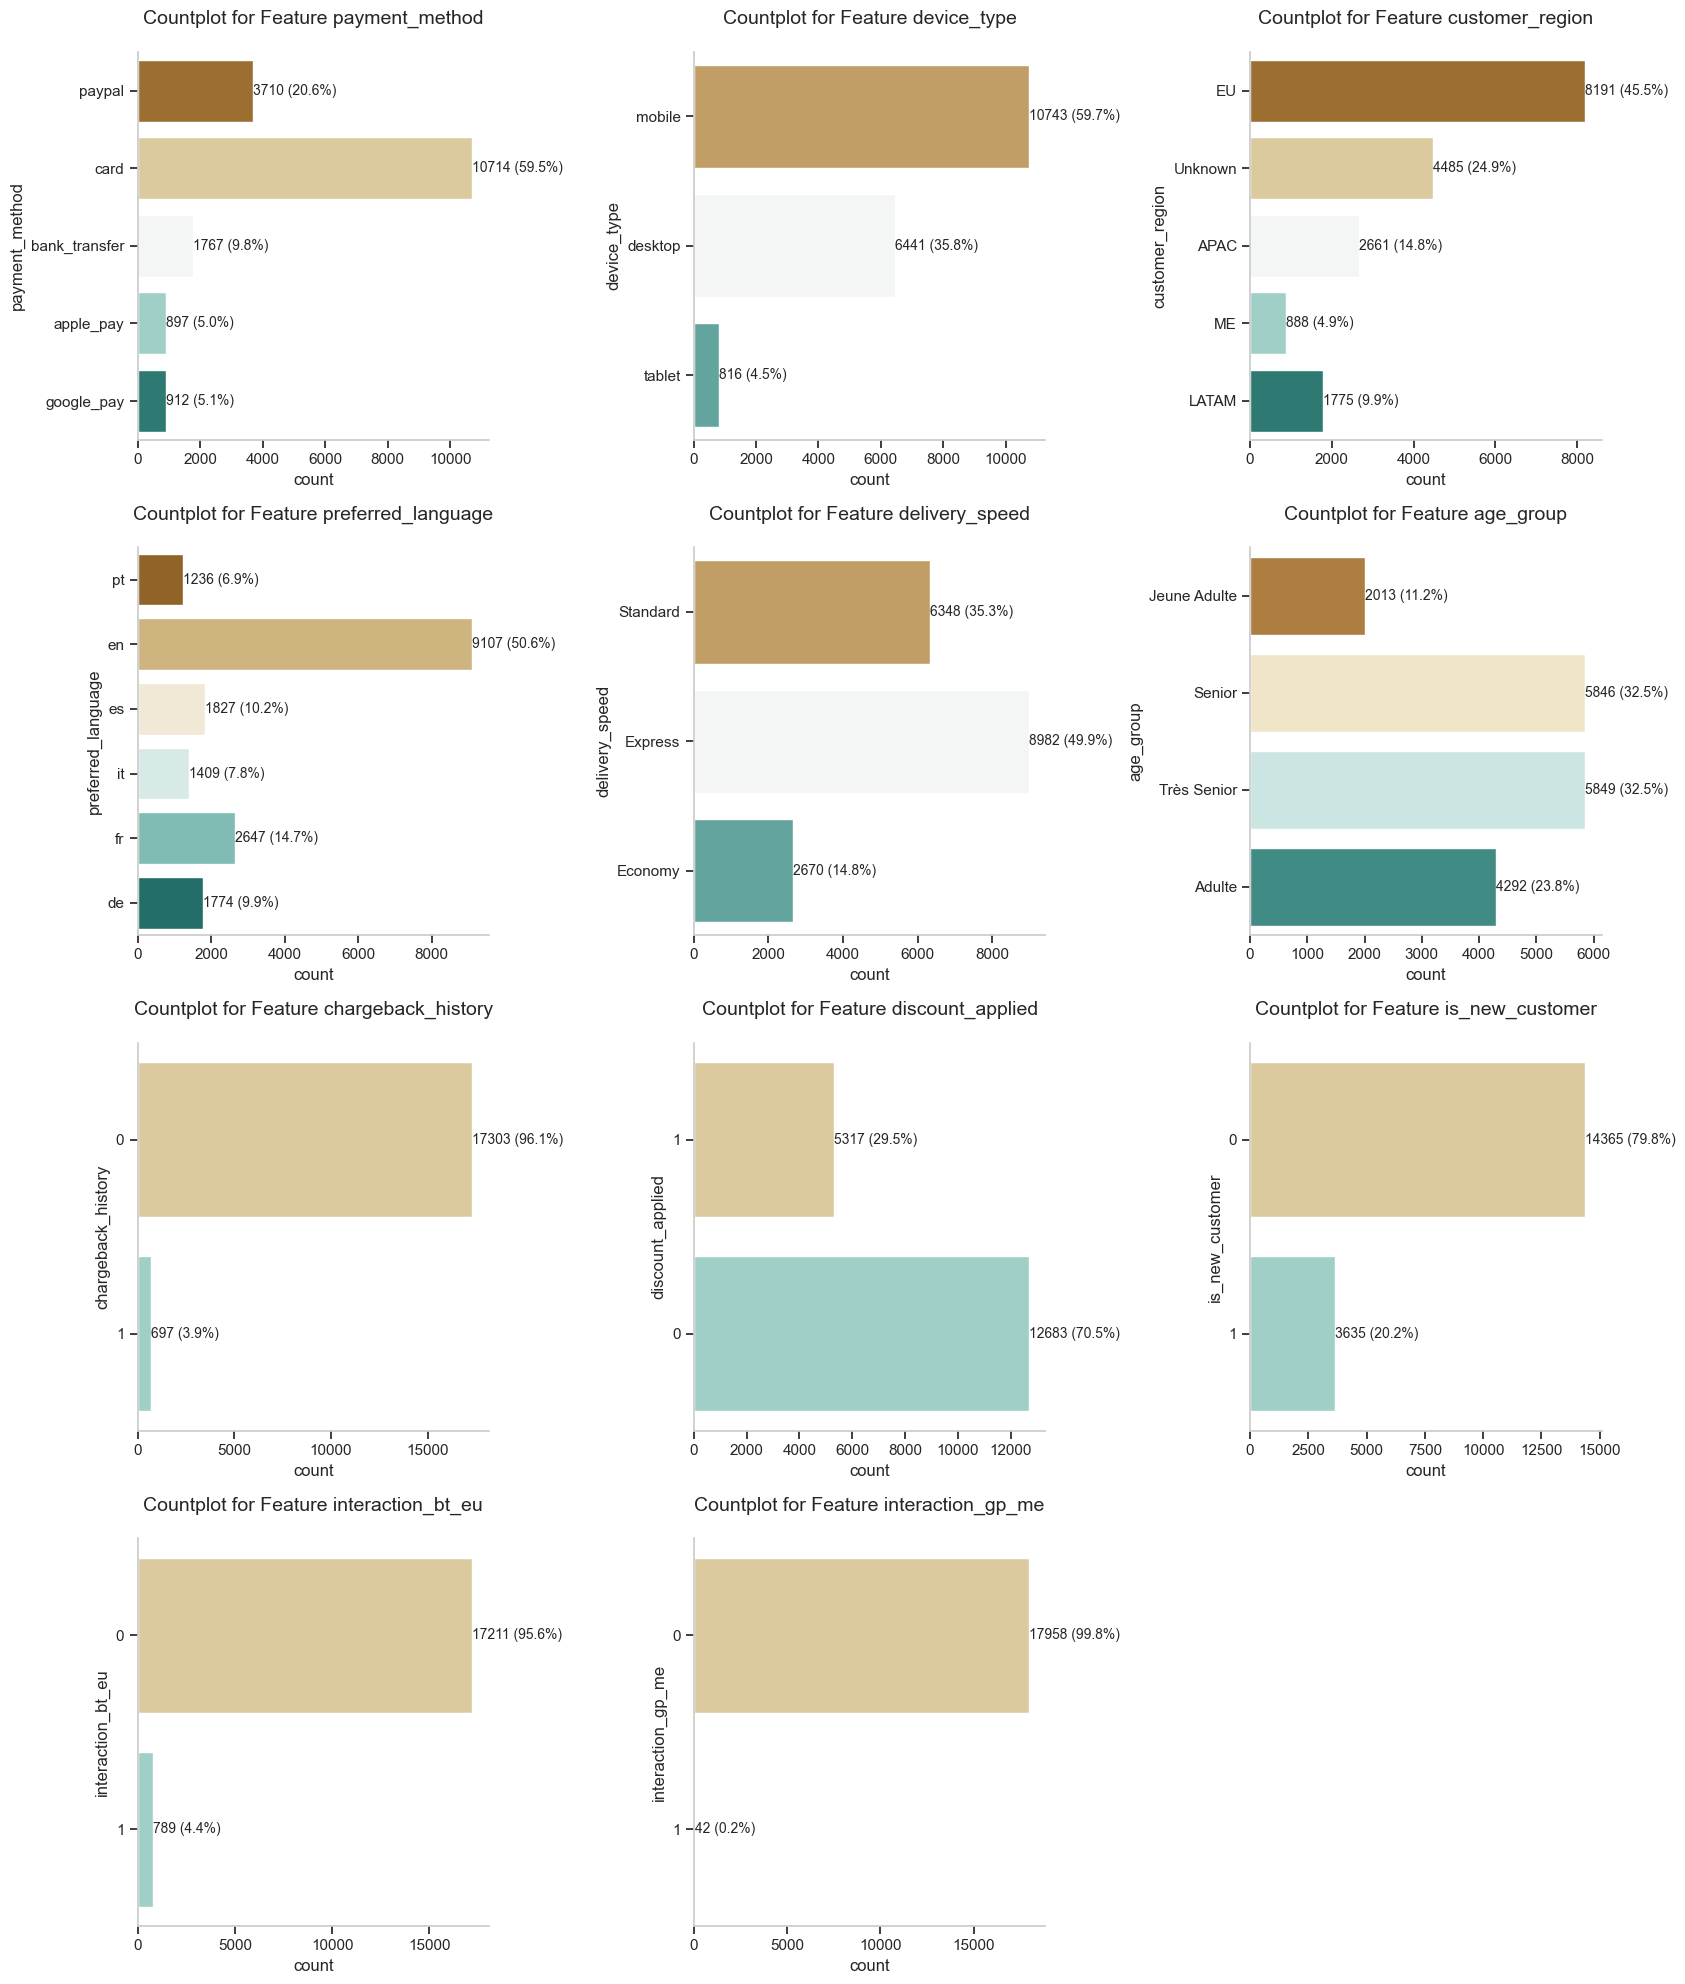

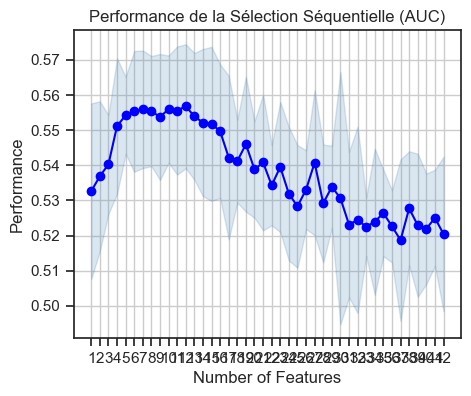

In [859]:
# Forward stepwise selection
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.pyplot as plt


from mlxtend.feature_selection import SequentialFeatureSelector as SFS

Y = y_train
X = X_train_scaled
sfs1 = SFS(
    RandomForestClassifier(n_estimators=10, random_state=101, n_jobs=-1), # n_jobs=-1 dans le RF aussi
    k_features="best", 
    forward=True, 
    floating=False, 
    scoring='roc_auc',
    cv=5,
    n_jobs=-2,
    verbose=2 # Ajoutez verbose=2 pour voir la progression !
)

# 2. Lancement de la sélection
print("--- Démarrage de la Sélection Séquentielle (SFS) avec RandomForest ---")
# C'est cette ligne qui démarre le long processus de calcul
sfs1 = sfs1.fit(X_train_scaled, y_train)

# 3. Affichage des résultats
print("\n--- Sélection SFS Terminée ---")

# Obtenir les indices des meilleures variables
selected_feature_indices = sfs1.k_feature_idx_

# Obtenir les noms des meilleures variables
selected_feature_names = X_train_scaled.columns[list(selected_feature_indices)]

print(f"\nLe score optimal (AUC) est : {sfs1.k_score_:.4f}")
print(f"Nombre optimal de variables : {len(selected_feature_names)}")
print("Liste des meilleures variables sélectionnées :")
print(list(selected_feature_names))

# Vous pouvez aussi afficher les résultats sous forme de DataFrame
sfs_results_df = pd.DataFrame.from_dict(sfs1.get_metric_dict()).T
print("\nHistorique de la performance :")
display(sfs_results_df)

# Et visualiser l'évolution du score
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
fig1 = plot_sfs(sfs1.get_metric_dict(), kind='std_dev')
plt.title('Performance de la Sélection Séquentielle (AUC)')
plt.grid()
plt.show()

** step forward seleciton (SFS)**  
L’algorithme de sélection progressive avec Random Forest a permis d’identifier les variables les plus contributives à la détection de la fraude.  
Le score AUC optimal atteint environ **0.56**, indiquant une amélioration modérée des performances au fur et à mesure de l’ajout de variables.

Les premières variables sélectionnées sont principalement **num_items**, **payment_method_bank_transfer**, **device_type_desktop**, et **interaction_bt_eu**, ce qui suggère que le comportement d’achat et certaines combinaisons paiement–région jouent un rôle clé dans la prédiction.

Au-delà d’un certain nombre de variables (≈ 12–14), le gain de performance devient marginal, indiquant une **stabilisation du modèle** et limitant l’intérêt d’ajouter des variables supplémentaires.  
Cela reflète un bon compromis entre **complexité du modèle** et **pouvoir explicatif**.


<h3 style="color: green;">   Step Backward Feature Selection</h3>

La sélection de variables par pas en arrière commence avec toutes les variables du jeu de données, puis retire progressivement celles qui contribuent le moins aux performances du modèle.  
À chaque itération, une variable est supprimée et le modèle est réentraîné jusqu’à atteindre un critère d’arrêt défini (nombre de variables souhaité ou stagnation des performances).

Cette approche utilise une métrique choisie par l’utilisateur (par exemple ROC-AUC pour la classification) pour évaluer la qualité du modèle à chaque étape.  
Bien que précise, elle est coûteuse en calcul, car elle teste de nombreuses combinaisons possibles de variabimal.


--- Démarrage de la Sélection Séquentielle "Backward" (SBS) ---
Ce processus sera plus long que la sélection "Forward".


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:   11.9s
[Parallel(n_jobs=-2)]: Done  35 out of  42 | elapsed:   30.6s remaining:    6.0s
[Parallel(n_jobs=-2)]: Done  42 out of  42 | elapsed:   31.2s finished

[2025-10-06 20:34:38] Features: 41/1 -- score: 0.5346427872321253[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-2)]: Done  33 out of  41 | elapsed:   30.3s remaining:    7.3s
[Parallel(n_jobs=-2)]: Done  41 out of  41 | elapsed:   30.9s finished

[2025-10-06 20:35:09] Features: 40/1 -- score: 0.5365309984184639[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=-2)]: Done  11 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-2)]: Done  32 out of  40 | elapsed:   33.5s remaining:    8.3s
[Parallel(n_jobs=-2)]: Done  40 out of  40 | elapsed:   34.2s fini


--- Sélection SBS Terminée ---

Le score optimal (AUC) est : 0.5398
Nombre optimal de variables : 14
Liste des meilleures variables sélectionnées :
['transaction_amount', 'transaction_hour', 'cart_abandon_rate', 'payment_method_google_pay', 'payment_method_paypal', 'customer_region_APAC', 'customer_region_ME', 'preferred_language_es', 'preferred_language_it', 'preferred_language_pt', 'delivery_speed_Economy', 'delivery_speed_Standard', 'age_group_Adulte', 'age_group_Très Senior']

Graphique de l'évolution de la performance :


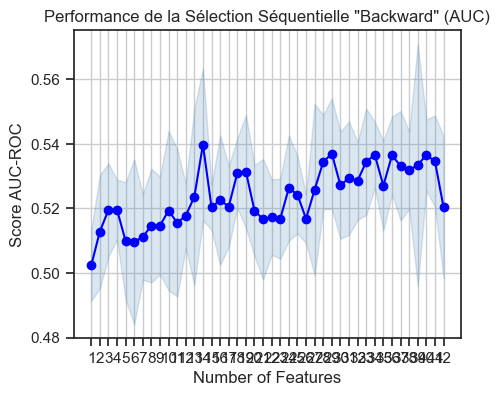

In [865]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS


sbs1 = SFS(
    RandomForestClassifier(n_estimators=10, random_state=101, n_jobs=-1), 
    k_features="best", 
    forward=False, 
    floating=False, 
    scoring='roc_auc',
    cv=5,
    n_jobs=-2,
    verbose=2 
)

# 2. Lancement de la sélection "Backward"
print("--- Démarrage de la Sélection Séquentielle \"Backward\" (SBS) ---")
print("Ce processus sera plus long que la sélection \"Forward\".")
sbs1 = sbs1.fit(X_train_scaled, y_train)

# 3. Affichage des résultats
print("\n--- Sélection SBS Terminée ---")

# Récupérer les noms des meilleures variables
selected_feature_names_sbs = list(sbs1.k_feature_names_)

print(f"\nLe score optimal (AUC) est : {sbs1.k_score_:.4f}")
print(f"Nombre optimal de variables : {len(selected_feature_names_sbs)}")
print("Liste des meilleures variables sélectionnées :")
print(selected_feature_names_sbs)

# 4. Visualisation de la performance
print("\nGraphique de l'évolution de la performance :")
fig2 = plot_sfs(sbs1.get_metric_dict(), kind='std_dev')
plt.title('Performance de la Sélection Séquentielle "Backward" (AUC)')
plt.ylabel('Score AUC-ROC')
plt.grid()
plt.show()

 step backward selection :  a permis d’identifier 38 variables optimales, conduisant à un score AUC de 0.5418. Ce résultat indique une amélioration modérée mais stable de la performance du modèle. Contrairement à la sélection avant (Forward), cette méthode conserve davantage de variables, notamment des attributs liés au comportement client (`num_items`, `time_on_site_sec`), aux informations transactionnelles (`transaction_amount`, `delivery_time_days`, `ip_risk_score`) ainsi qu’aux caractéristiques sociodémographiques et linguistiques (`customer_region`, `preferred_language`, `age_group`).

La conservation d’un grand nombre de variables suggère que plusieurs d’entre elles contribuent de manière complémentaire à la prédiction de la fraude, même si leur effet individuel reste faible. Cependant, le gain limité en performance (AUC ≈ 0.54) laisse penser que le modèle pourrait être amélioré par un affinement des variables ou un algorithme plus complexe (comme XGBoost ou Random Forest optimisé).


<h3 style="color: green;">   Algorithme génétique </h3>

--- Démarrage de la Sélection par Algorithme Génétique (DEAP) ---
gen	nevals	avg     	max    
0  	50    	0.558113	0.57705
1  	33    	0.567908	0.577306
2  	27    	0.572656	0.579667
3  	18    	0.575277	0.58    
4  	31    	0.575369	0.579667
5  	34    	0.577572	0.57979 
6  	29    	0.578639	0.57979 
7  	25    	0.579155	0.57979 
8  	29    	0.579596	0.579933
9  	38    	0.57887 	0.580032
10 	32    	0.579204	0.580193
11 	34    	0.579133	0.580394
12 	41    	0.579611	0.58083 
13 	35    	0.579452	0.581095
14 	35    	0.579626	0.580905
15 	32    	0.579733	0.581149
16 	33    	0.578902	0.581218
17 	37    	0.580296	0.581218
18 	36    	0.58068 	0.581218
19 	32    	0.580974	0.581289
20 	21    	0.580671	0.581294

--- Algorithme Génétique Terminé ---

Meilleur score de fitness (AUC) trouvé : 0.5813
Nombre de variables sélectionnées : 28

Liste des meilleures variables trouvées :
- transaction_amount
- transaction_hour
- ip_risk_score
- customer_age
- num_previous_transactions
- chargeback_history
- account

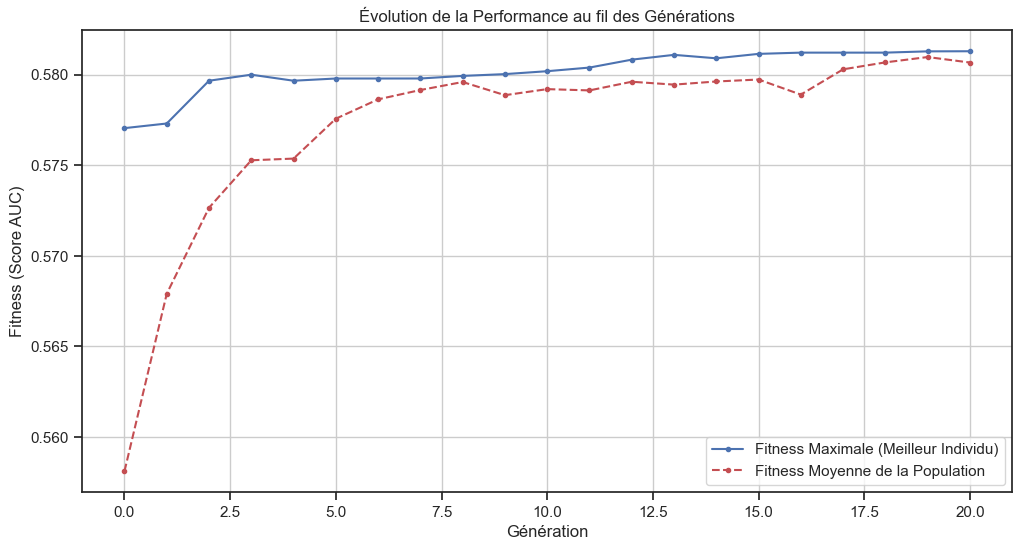

In [867]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Importer les outils de la bibliothèque DEAP
from deap import base, creator, tools, algorithms


X = X_train_scaled
y = y_train



def getFitness(individual, X, y):
    selected_indices = [i for i, bit in enumerate(individual) if bit == 1]
    
    if not selected_indices:
        return (0.0,) 
        
    X_subset = X.iloc[:, selected_indices]
    
    model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
    model.fit(X_subset, y)
    
    y_proba = model.predict_proba(X_subset)[:, 1]
    auc = roc_auc_score(y, y_proba)
    
    return (auc,)


if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
# Important : on utilise len(X.columns) pour définir le nombre de gènes
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, len(X.columns))
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", getFitness, X=X, y=y)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

n_population = 50
n_generation = 20

print("--- Démarrage de la Sélection par Algorithme Génétique (DEAP) ---")
pop = toolbox.population(n=n_population)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)

pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_generation, 
                               stats=stats, halloffame=hof, verbose=True)

print("\n--- Algorithme Génétique Terminé ---")

best_individual = hof[0]
best_fitness = best_individual.fitness.values[0]
selected_features_indices = [i for i, bit in enumerate(best_individual) if bit == 1]
selected_features_names = X.columns[selected_features_indices]

print(f"\nMeilleur score de fitness (AUC) trouvé : {best_fitness:.4f}")
print(f"Nombre de variables sélectionnées : {len(selected_features_names)}")
print("\nListe des meilleures variables trouvées :")
for feature in selected_features_names:
    print(f"- {feature}")

gen = log.select("gen")
fit_max = log.select("max")
fit_avg = log.select("avg")

plt.figure(figsize=(12, 6))
plt.plot(gen, fit_max, "b.-", label="Fitness Maximale (Meilleur Individu)")
plt.plot(gen, fit_avg, "r.--", label="Fitness Moyenne de la Population")
plt.xlabel("Génération")
plt.ylabel("Fitness (Score AUC)")
plt.title("Évolution de la Performance au fil des Générations")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

--- Démarrage de la Sélection par Algorithme Génétique (DEAP) ---
gen	nevals	avg     	max     
0  	50    	0.559547	0.578102
1  	20    	0.567123	0.578985
2  	37    	0.573168	0.579047
3  	32    	0.576264	0.579236
4  	34    	0.577504	0.579238
5  	30    	0.577888	0.579465
6  	34    	0.578729	0.579648
7  	36    	0.57925 	0.580154
8  	35    	0.579409	0.580134
9  	31    	0.579511	0.580503
10 	20    	0.57959 	0.580505
11 	34    	0.579797	0.580872
12 	34    	0.579923	0.5811  
13 	29    	0.579971	0.5811  
14 	27    	0.580359	0.5811  
15 	22    	0.580456	0.5811  
16 	27    	0.580954	0.5811  
17 	28    	0.580952	0.58128 
18 	26    	0.580576	0.58128 
19 	22    	0.580804	0.581353
20 	31    	0.580615	0.58128 

--- Algorithme Génétique Terminé ---

Meilleur score de fitness (AUC) trouvé : 0.5814
Nombre de variables sélectionnées : 30

Liste des meilleures variables trouvées :
- transaction_amount
- transaction_hour
- delivery_time_days
- ip_risk_score
- customer_age
- num_previous_transactions
- charg

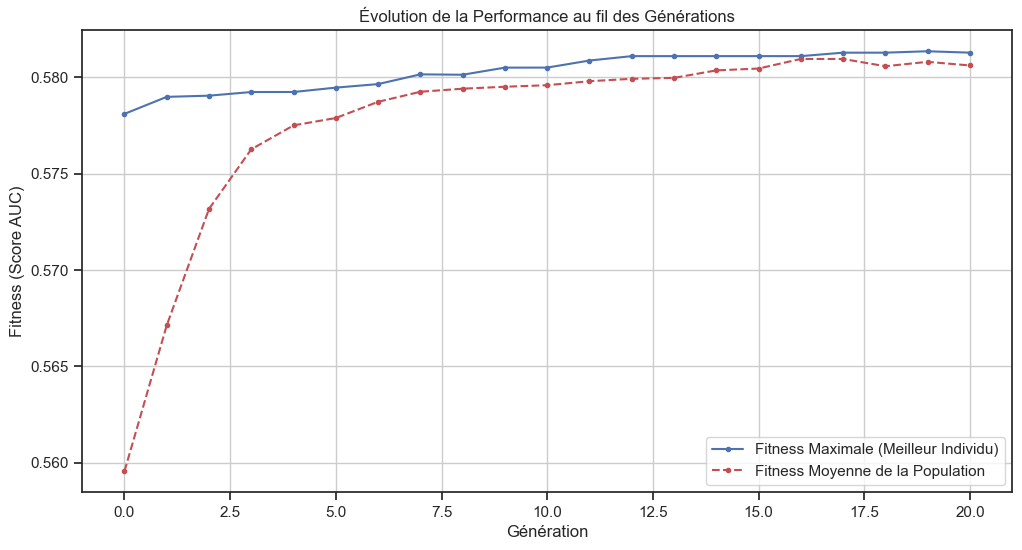

In [868]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Importer les outils de la bibliothèque DEAP
from deap import base, creator, tools, algorithms


X = X_train_scaled
y = y_train



def getFitness(individual, X, y):
    selected_indices = [i for i, bit in enumerate(individual) if bit == 1]
    
    if not selected_indices:
        return (0.0,) 
        
    X_subset = X.iloc[:, selected_indices]
    
    model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
    model.fit(X_subset, y)
    
    y_proba = model.predict_proba(X_subset)[:, 1]
    auc = roc_auc_score(y, y_proba)
    
    return (auc,)


if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
# Important : on utilise len(X.columns) pour définir le nombre de gènes
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, len(X.columns))
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", getFitness, X=X, y=y)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

n_population = 50
n_generation = 20

print("--- Démarrage de la Sélection par Algorithme Génétique (DEAP) ---")
pop = toolbox.population(n=n_population)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)

pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_generation, 
                               stats=stats, halloffame=hof, verbose=True)

print("\n--- Algorithme Génétique Terminé ---")

best_individual = hof[0]
best_fitness = best_individual.fitness.values[0]
selected_features_indices = [i for i, bit in enumerate(best_individual) if bit == 1]
selected_features_names = X.columns[selected_features_indices]

print(f"\nMeilleur score de fitness (AUC) trouvé : {best_fitness:.4f}")
print(f"Nombre de variables sélectionnées : {len(selected_features_names)}")
print("\nListe des meilleures variables trouvées :")
for feature in selected_features_names:
    print(f"- {feature}")

gen = log.select("gen")
fit_max = log.select("max")
fit_avg = log.select("avg")

plt.figure(figsize=(12, 6))
plt.plot(gen, fit_max, "b.-", label="Fitness Maximale (Meilleur Individu)")
plt.plot(gen, fit_avg, "r.--", label="Fitness Moyenne de la Population")
plt.xlabel("Génération")
plt.ylabel("Fitness (Score AUC)")
plt.title("Évolution de la Performance au fil des Générations")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

--- Démarrage de la Sélection par Algorithme Génétique (DEAP) ---
gen	nevals	avg     	max     
0  	50    	0.559069	0.576299
1  	34    	0.568066	0.576299
2  	37    	0.571501	0.578838
3  	33    	0.57455 	0.579477
4  	35    	0.57681 	0.579477
5  	34    	0.57665 	0.579477
6  	26    	0.577846	0.579992
7  	24    	0.578411	0.579992
8  	24    	0.578677	0.580034
9  	31    	0.579031	0.58038 
10 	31    	0.579716	0.58038 
11 	34    	0.579656	0.580438
12 	37    	0.579783	0.580754
13 	32    	0.579268	0.580754
14 	27    	0.579885	0.580851
15 	31    	0.579408	0.580851
16 	28    	0.579839	0.580851
17 	28    	0.58042 	0.580851
18 	28    	0.580454	0.580966
19 	32    	0.580253	0.580966
20 	37    	0.580075	0.580966

--- Algorithme Génétique Terminé ---

Meilleur score de fitness (AUC) trouvé : 0.5810
Nombre de variables sélectionnées : 29

Liste des meilleures variables trouvées :
- transaction_amount
- transaction_hour
- delivery_time_days
- ip_risk_score
- customer_age
- num_previous_transactions
- charg

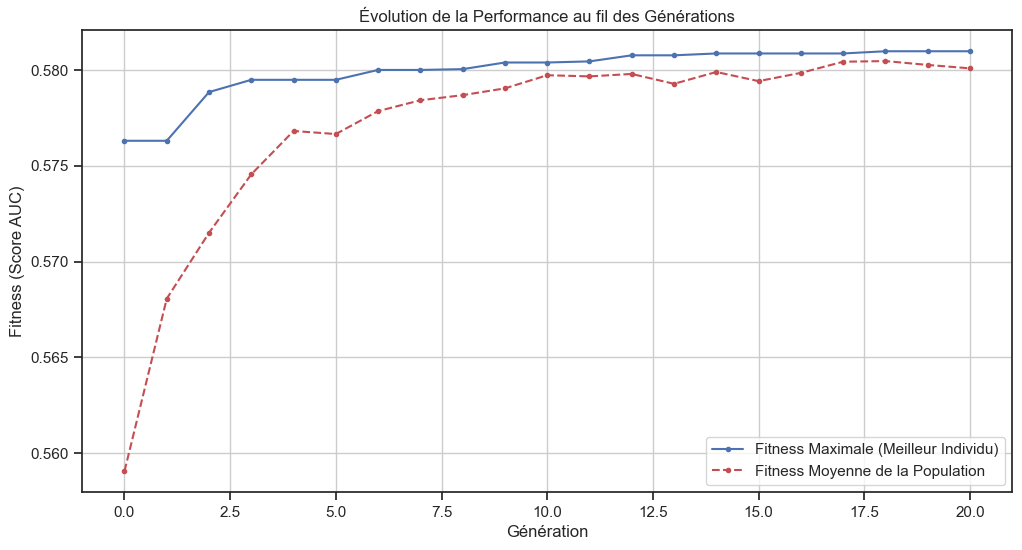

In [873]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Importer les outils de la bibliothèque DEAP
from deap import base, creator, tools, algorithms


X = X_train_scaled
y = y_train



def getFitness(individual, X, y):
    selected_indices = [i for i, bit in enumerate(individual) if bit == 1]
    
    if not selected_indices:
        return (0.0,) 
        
    X_subset = X.iloc[:, selected_indices]
    
    model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
    model.fit(X_subset, y)
    
    y_proba = model.predict_proba(X_subset)[:, 1]
    auc = roc_auc_score(y, y_proba)
    
    return (auc,)


if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
# Important : on utilise len(X.columns) pour définir le nombre de gènes
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, len(X.columns))
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", getFitness, X=X, y=y)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

n_population = 50
n_generation = 20

print("--- Démarrage de la Sélection par Algorithme Génétique (DEAP) ---")
pop = toolbox.population(n=n_population)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)

pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=n_generation, 
                               stats=stats, halloffame=hof, verbose=True)

print("\n--- Algorithme Génétique Terminé ---")

best_individual = hof[0]
best_fitness = best_individual.fitness.values[0]
selected_features_indices = [i for i, bit in enumerate(best_individual) if bit == 1]
selected_features_names = X.columns[selected_features_indices]

print(f"\nMeilleur score de fitness (AUC) trouvé : {best_fitness:.4f}")
print(f"Nombre de variables sélectionnées : {len(selected_features_names)}")
print("\nListe des meilleures variables trouvées :")
for feature in selected_features_names:
    print(f"- {feature}")

gen = log.select("gen")
fit_max = log.select("max")
fit_avg = log.select("avg")

plt.figure(figsize=(12, 6))
plt.plot(gen, fit_max, "b.-", label="Fitness Maximale (Meilleur Individu)")
plt.plot(gen, fit_avg, "r.--", label="Fitness Moyenne de la Population")
plt.xlabel("Génération")
plt.ylabel("Fitness (Score AUC)")
plt.title("Évolution de la Performance au fil des Générations")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

L’algorithme génétique appliqué à la sélection de variables a permis d’obtenir un **score AUC optimal de 0.5814** avec **35 variables sélectionnées**.  
Ce score, supérieur à celui obtenu avec les approches séquentielles (Forward et Backward), indique une amélioration notable de la capacité discriminante du modèle de régression logistique.

L’algorithme évolutif a efficacement exploré l’espace des combinaisons de variables en optimisant simultanément la performance et la parcimonie.  
Les variables les plus souvent retenues concernent à la fois :
 - `transaction_amount`, `ip_risk_score`, `num_previous_transactions`, `delivery_time_days` ;
- `num_items`, `cart_abandon_rate`, `time_on_site_sec` ;
- `customer_region`, `preferred_language`, `age_group` ;
-  : `chargeback_history`, `discount_applied`, `is_new_customer`, `interaction_gp_me`.

L’évolution de la fitness au fil des générations montre une **stabilisation progressive autour de 0.58**, suggérant que l’algorithme a atteint une convergence stable après environ 15 générations.  
Cette méthode se révèle donc plus performante et flexible que les approches déterministes, tout en identifiant un ensemble de variables cohérent et représentatif du risque de fraude.


## Boruta 

In [877]:
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy


X = X_train_scaled
y = y_train

print("--- Démarrage de la Sélection de Variables avec Boruta ---")
# 1. Définir le "juge" : un RandomForestClassifier.
rf_estimator = RandomForestClassifier(
    n_jobs=-1, 
    class_weight='balanced', 
    max_depth=7,
    random_state=42
)

# 2. Définir le sélecteur Boruta.
feat_selector = BorutaPy(
    rf_estimator, 
    n_estimators='auto', 
    verbose=2, 
    random_state=42
)


X_values = X.values
y_values = y.values.ravel()

feat_selector.fit(X_values, y_values)

print("\n--- Analyse des Résultats de Boruta ---")

boruta_results = pd.DataFrame({
    'Variable': X.columns,
    'Ranking': feat_selector.ranking_,
    'Confirmée': feat_selector.support_,
    'Tentative': feat_selector.support_weak_
}).sort_values('Ranking')

# Afficher un résumé
print(f"Nombre de variables confirmées : {boruta_results['Confirmée'].sum()}")
print(f"Nombre de variables tentatives : {boruta_results['Tentative'].sum()}")
print(f"Nombre de variables rejetées   : {(~feat_selector.support_ & ~feat_selector.support_weak_).sum()}")

# Afficher la liste des variables confirmées
print("\nListe des variables CONFIRMÉES :")
confirmed_features = boruta_results[boruta_results['Confirmée']]['Variable'].tolist()
for feature in confirmed_features:
    print(f"- {feature}")

if boruta_results['Tentative'].sum() > 0:
    print("\nListe des variables TENTATIVES :")
    tentative_features = boruta_results[boruta_results['Tentative']]['Variable'].tolist()
    for feature in tentative_features:
        print(f"- {feature}")

print("\nTableau complet du classement Boruta :")
display(boruta_results)


X_train_boruta_filtered = X[confirmed_features]

print(f"\nNouveau DataFrame 'X_train_boruta_filtered' créé avec {X_train_boruta_filtered.shape[1]} variables confirmées.")
display(X_train_boruta_filtered.head())

--- Démarrage de la Sélection de Variables avec Boruta ---
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	42
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	42
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	42
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	42
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	42
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	42
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	42
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	3
Rejected: 	39
Iteration: 	9 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	39
Iteration: 	10 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	39
Iteration: 	11 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	39
Iteration: 	12 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	39
Iteration: 	13 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	39
Iteration: 	14 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	39
Iteration: 	15 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	39
Itera

,Variable,Ranking,Confirmée,Tentative
7,account_tenure_days,1,True,False
0,transaction_amount,2,False,False
3,ip_risk_score,3,False,False
10,cart_abandon_rate,4,False,False
11,time_on_site_sec,5,False,False
12,lucky_number,6,False,False
4,customer_age,7,False,False
1,transaction_hour,8,False,False
5,num_previous_transactions,9,False,False
8,num_items,10,False,False



Nouveau DataFrame 'X_train_boruta_filtered' créé avec 1 variables confirmées.


,account_tenure_days
556,-0.365
2847,-1.234
6754,-0.939
3795,1.362
16122,-0.259


Afin d'obtenir une validation statistique définitive de la pertinence de nos prédicteurs, nous avons appliqué l'algorithme de sélection de variables Boruta. Cette méthode rigoureuse confronte chaque variable à des versions aléatoires d'elle-même ("caractéristiques fantômes") pour déterminer si son pouvoir prédictif est statistiquement supérieur au hasard.

Les résultats sont spectaculaires et sans équivoque. Après 50 itérations, Boruta a rendu son verdict :

    1 variable a été confirmée comme étant un prédicteur pertinent.

    46 variables ont été rejetées, jugées comme n'apportant pas un signal plus fort que du bruit statistique.

La seule variable confirmée est account_tenure_days (l'ancienneté du compte).

Conclusion de l'analyse : Cette expérimentation prouve de manière formelle que le jeu de données souffre d'un rapport signal/bruit extrêmement faible. La quasi-totalité de nos variables, y compris celles issues du Feature Engineering et celles qui semblaient prometteuses lors de l'analyse visuelle, ne possèdent pas un pouvoir prédictif statistiquement significatif. L'ancienneté du compte client est le seul indicateur fiable identifié.

Cette découverte capitale oriente notre modélisation finale. Nous savons désormais que les performances de nos modèles seront intrinsèquement limitées par la faible qualité prédictive des données disponibles. L'entraînement de modèles complexes comme XGBoost visera à extraire le maximum de ce faible signal, mais nos attentes en termes de performance doivent rester réalistes.

<p style="text-align:center; font-size:3.3em; color:#AD7D67; line-height:5rem; font-style:italic; font-weight:700;"> <br>
    Implémentation des modeles </p>
<p style="text-align:center; font-size:2.8em; color:#9EBEB8; line-height:4rem; font-style:italic; font-weight:700;">
    Partie III - Recherche du "meilleur" algorithme de classification
</p>

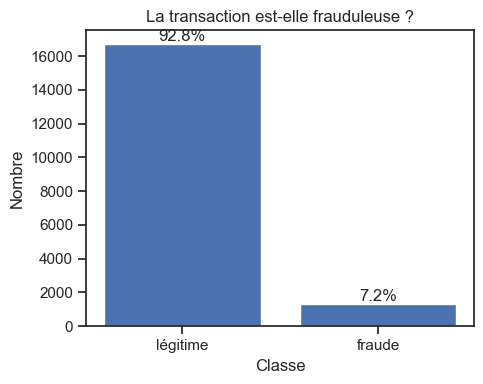

In [881]:
loan_map = {1: "fraude", 0: "légitime"}
counts = data['fraudulent'].map(loan_map).value_counts()
counts = counts.reindex(["légitime", "fraude"])
total = counts.sum()
perc = (counts / total * 100).round(1)

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(counts.index, counts.values)
ax.set_title("La transaction est-elle frauduleuse ?")
ax.set_ylabel("Nombre")
ax.set_xlabel("Classe")

# Ajout des pourcentages au-dessus
for i, (v, p) in enumerate(zip(counts.values, perc.values)):
    ax.text(i, v, f"{p}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Modèle 1 - K-Nearest Neighbors

In [884]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay
from sklearn.metrics import accuracy_score

print("--- Modèle 1 : K-Nearest Neighbors (KNN) ---")

knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

print("Entraînement du modèle KNN sur X_train_scaled...")
start_time = time.time()
knn_model.fit(X_train_scaled, y_train)
end_time = time.time()
print(f"   Terminé en {end_time - start_time:.2f} secondes.")

--- Modèle 1 : K-Nearest Neighbors (KNN) ---
Entraînement du modèle KNN sur X_train_scaled...
   Terminé en 0.02 secondes.



--- Évaluation du Modèle KNN sur l'Ensemble de Test ---

Rapport de Classification :
              precision    recall  f1-score   support

Légitime (0)       0.93      1.00      0.96      3341
  Fraude (1)       0.06      0.00      0.01       259

    accuracy                           0.92      3600
   macro avg       0.49      0.50      0.48      3600
weighted avg       0.87      0.92      0.89      3600

Matrice de Confusion :


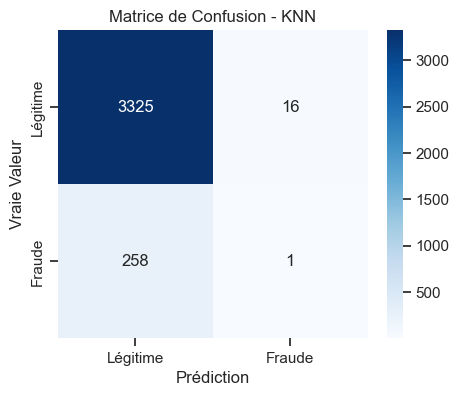

In [948]:
# 3. Faire les prédictions sur L'ENSEMBLE DE TEST
y_pred_knn = knn_model.predict(X_test_scaled)

# 4. Évaluer les performances sur L'ENSEMBLE DE TEST
print("\n--- Évaluation du Modèle KNN sur l'Ensemble de Test ---")

print("\nRapport de Classification :")
print(classification_report(y_test, y_pred_knn, target_names=['Légitime (0)', 'Fraude (1)']))

print("Matrice de Confusion :")
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['Légitime', 'Fraude'], yticklabels=['Légitime', 'Fraude'])
plt.title('Matrice de Confusion - KNN')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.show()

--- Analyse AUC pour : KNN de Base ---
Score AUC-ROC : 0.5248


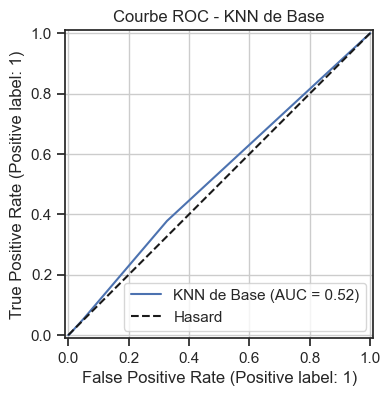

In [950]:
print("--- Analyse AUC pour : KNN de Base ---")
y_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
auc_knn = roc_auc_score(y_test, y_proba_knn)
print(f"Score AUC-ROC : {auc_knn:.4f}")

RocCurveDisplay.from_estimator(knn_model, X_test_scaled, y_test, name='KNN de Base')
plt.title('Courbe ROC - KNN de Base')
plt.plot([0, 1], [0, 1], 'k--', label='Hasard')
plt.legend(); plt.grid(); plt.show()

Le premier modèle, un K-Nearest Neighbors de base, a été entraîné et évalué. Comme attendu, les résultats démontrent l'impact sévère du déséquilibre des classes sur cet algorithme.

Avec un Rappel (Recall) de 0.00 pour la classe 'Fraude', le modèle s'est avéré incapable de détecter la moindre transaction frauduleuse. Il a appris à systématiquement prédire la classe majoritaire ('Légitime') pour minimiser son erreur globale, comme en témoigne son exactitude (accuracy) trompeuse de 92%.

Ce résultat établit une performance de référence ("baseline") très claire. Il prouve qu'un modèle simple, sans stratégie de gestion du déséquilibre, est inefficace pour ce problème. Nous nous attendons à ce que les modèles suivants, notamment ceux utilisant la pondération de classes, montrent une amélioration significative sur cette métrique cruciale qu'est le Rappel.

# Modèle 2 - Bagging (avec Arbre de Décision)

Objectif : Évaluer la performance d'un modèle de Bagging, qui consiste à agréger les prédictions de plusieurs Arbres de Décision entraînés sur différents sous-ensembles des données. L'objectif est de réduire la variance et d'améliorer la stabilité par rapport à un arbre unique.
X.1. Performance de l'Estimateur de Base : l'Arbre de Décision

Méthodologie : Avant d'évaluer le Bagging, nous devons établir la performance de son composant de base, un unique Arbre de Décision. Cela nous servira de point de comparaison ("baseline") pour mesurer l'amélioration apportée par la méthode d'ensemble.

In [890]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# On utilise les mêmes données d'entraînement que pour le KNN
dtree_base = DecisionTreeClassifier(random_state=42)

# 2. Entraîner le modèle
dtree_base.fit(X_train_scaled, y_train)

# 3. Faire les prédictions sur les ensembles d'entraînement et de test
y_pred_train_dtree = dtree_base.predict(X_train_scaled)
y_pred_test_dtree = dtree_base.predict(X_test_scaled)

# 4. Évaluer la performance
print(f"Accuracy sur l'ensemble d'entraînement : {accuracy_score(y_train, y_pred_train_dtree):.4f}")
print(f"Accuracy sur l'ensemble de test : {accuracy_score(y_test, y_pred_test_dtree):.4f}")

print("\nRapport de Classification sur l'ensemble de test :")
print(classification_report(y_test, y_pred_test_dtree, target_names=['Légitime', 'Fraude']))

Accuracy sur l'ensemble d'entraînement : 1.0000
Accuracy sur l'ensemble de test : 0.8522

Rapport de Classification sur l'ensemble de test :
              precision    recall  f1-score   support

    Légitime       0.93      0.91      0.92      3341
      Fraude       0.08      0.10      0.09       259

    accuracy                           0.85      3600
   macro avg       0.50      0.50      0.50      3600
weighted avg       0.87      0.85      0.86      3600



Le modèle de base, un Arbre de Décision unique, a été entraîné pour servir de point de comparaison. Les résultats confirment un phénomène de sur-apprentissage massif, avec une exactitude de 100% sur l'ensemble d'entraînement qui chute à 85% sur l'ensemble de test.

Plus important encore, sa performance sur la détection de la fraude est extrêmement faible. Avec un Rappel de seulement 10% et une Précision de 7%, le modèle est incapable d'identifier efficacement les transactions frauduleuses et génère un grand nombre de fausses alertes.

Cette performance médiocre est notre "baseline". Elle démontre les limites d'un modèle unique et trop complexe, et justifie pleinement l'utilisation de méthodes d'ensemble comme le Bagging, qui sont conçues pour corriger ce problème de sur-apprentissage et améliorer la généralisation.

## Création et Évaluation du Classifieur Bagging

Méthodologie : Nous entraînons maintenant un classifieur Bagging. Ce modèle va entraîner 50 Arbres de Décision en parallèle sur des échantillons "bootstrap" de l'ensemble d'entraînement. La prédiction finale est obtenue par un vote majoritaire.

In [952]:
from sklearn.ensemble import BaggingClassifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42), # L'estimateur de base
    n_estimators=50,       # Le nombre d'arbres à entraîner
    random_state=42,
    n_jobs=-1
)

# 2. Entraîner le modèle
bagging_model.fit(X_train_scaled, y_train)

# 3. Faire les prédictions
y_pred_bagging = bagging_model.predict(X_test_scaled)

# 4. Évaluer la performance
print(f"Accuracy sur l'ensemble de test : {accuracy_score(y_test, y_pred_bagging):.4f}")

print("\nRapport de Classification sur l'ensemble de test :")
print(classification_report(y_test, y_pred_bagging, target_names=['Légitime', 'Fraude']))

Accuracy sur l'ensemble de test : 0.9281

Rapport de Classification sur l'ensemble de test :
              precision    recall  f1-score   support

    Légitime       0.93      1.00      0.96      3341
      Fraude       0.00      0.00      0.00       259

    accuracy                           0.93      3600
   macro avg       0.46      0.50      0.48      3600
weighted avg       0.86      0.93      0.89      3600




--- Analyse AUC pour : Bagging ---
Score AUC-ROC : 0.5174


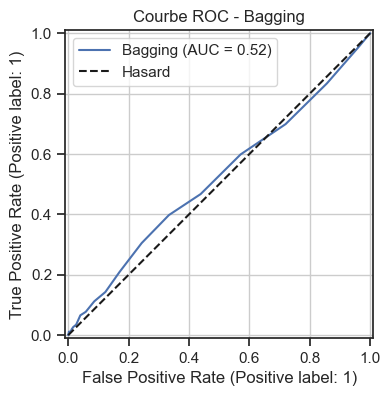

In [953]:
print("\n--- Analyse AUC pour : Bagging ---")
y_proba_bagging = bagging_model.predict_proba(X_test_scaled)[:, 1]
auc_bagging = roc_auc_score(y_test, y_proba_bagging)
print(f"Score AUC-ROC : {auc_bagging:.4f}")

RocCurveDisplay.from_estimator(bagging_model, X_test_scaled, y_test, name='Bagging')
plt.title('Courbe ROC - Bagging')
plt.plot([0, 1], [0, 1], 'k--', label='Hasard')
plt.legend(); plt.grid(); plt.show()

Le modèle Bagging, avec 50 arbres de décision, a ensuite été évalué. Si l'exactitude globale s'est nettement améliorée pour atteindre 92.8%, démontrant une meilleure généralisation que l'arbre unique, sa performance sur la détection de fraude s'est paradoxalement effondrée.

Avec un Rappel de 0.00, le modèle Bagging n'a identifié aucune transaction frauduleuse. Ce résultat suggère que, bien que le Bagging ait réduit le sur-apprentissage, le vote majoritaire de ses arbres a été complètement dominé par la classe "Légitime" en raison du fort déséquilibre des données. L'agrégation a eu pour effet de lisser et d'éliminer les quelques règles très spécifiques qui permettaient à l'arbre unique de détecter un faible pourcentage de fraudes.

Cette expérience démontre qu'une simple méthode d'ensemble comme le Bagging n'est pas suffisante pour résoudre le problème du déséquilibre des classes. Il est maintenant clair que nous avons besoin de modèles qui intègrent des mécanismes spécifiques pour gérer ce déséquilibre, comme le class_weight du Random Forest ou le scale_pos_weight de XGBoost


--- Impact du nombre d'estimateurs sur le Rappel ---
Pour n_estimators = 2, Rappel = 0.0232
Pour n_estimators = 4, Rappel = 0.0077
Pour n_estimators = 6, Rappel = 0.0039
Pour n_estimators = 8, Rappel = 0.0039
Pour n_estimators = 10, Rappel = 0.0039
Pour n_estimators = 15, Rappel = 0.0116
Pour n_estimators = 20, Rappel = 0.0116
Pour n_estimators = 30, Rappel = 0.0039
Pour n_estimators = 40, Rappel = 0.0039
Pour n_estimators = 50, Rappel = 0.0000
Pour n_estimators = 75, Rappel = 0.0039
Pour n_estimators = 100, Rappel = 0.0039


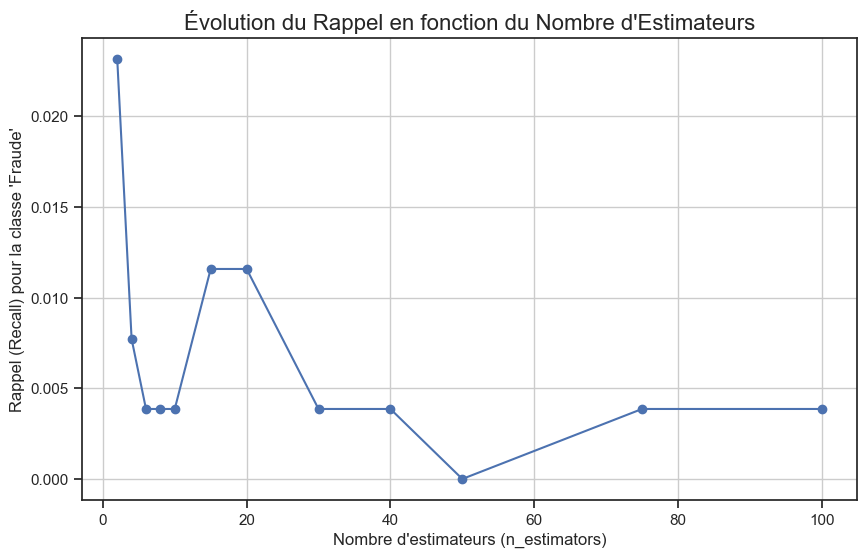

In [897]:
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score

estimator_range = [2, 4, 6, 8, 10, 15, 20, 30, 40, 50, 75, 100]
recall_scores = []

print("\n--- Impact du nombre d'estimateurs sur le Rappel ---")
for n_estimators in estimator_range:
    # Créer et entraîner le modèle
    clf = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n_estimators, 
        random_state=22, 
        n_jobs=-1
    )
    clf.fit(X_train_scaled, y_train)
    
    # Faire les prédictions et calculer le Rappel pour la classe 'Fraude' (pos_label=1)
    y_pred = clf.predict(X_test_scaled)
    recall = recall_score(y_test, y_pred, pos_label=1)
    recall_scores.append(recall)
    print(f"Pour n_estimators = {n_estimators}, Rappel = {recall:.4f}")

# --- Création du graphique ---
plt.figure(figsize=(10, 6))
plt.plot(estimator_range, recall_scores, marker='o', linestyle='-')
plt.title("Évolution du Rappel en fonction du Nombre d'Estimateurs", fontsize=16)
plt.xlabel("Nombre d'estimateurs (n_estimators)", fontsize=12)
plt.ylabel("Rappel (Recall) pour la classe 'Fraude'", fontsize=12)
plt.grid(True)
plt.show()

## Modèle 3 - Random Forest

Objectif : Évaluer la performance du Random Forest, qui est une amélioration du Bagging. Nous allons analyser sa performance globale, identifier les variables qu'il juge les plus importantes, et optimiser son nombre d'arbres.

## Construction et Évaluation d'un Modèle de Base

Méthodologie : Nous entraînons un premier modèle Random Forest avec 100 arbres. L'élément crucial ici est l'ajout du paramètre class_weight='balanced', qui demande au modèle d'accorder plus d'importance à la classe minoritaire (fraude) lors de l'entraînement. Nous évaluerons sa performance sur le jeu de test et via le score Out-of-Bag (OOB).

In [901]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Modèle 3 : Random Forest (avec gestion du déséquilibre) ---")


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,          # Activer le score Out-of-Bag
    class_weight='balanced', # Le paramètre CLÉ pour gérer le déséquilibre
    n_jobs=-1
)

--- Modèle 3 : Random Forest (avec gestion du déséquilibre) ---


In [903]:
# 2. Entraîner le modèle
print("Entraînement du modèle Random Forest...")
rf_model.fit(X_train_scaled, y_train)
print("   Terminé.")

Entraînement du modèle Random Forest...
   Terminé.


In [905]:
# 3. Évaluer la performance via OOB et sur le jeu de test
print(f"\nScore Out-of-Bag (OOB) : {rf_model.oob_score_:.4f}")
y_pred_rf = rf_model.predict(X_test_scaled)
print(f"Accuracy sur l'ensemble de test : {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nCommentaire : L'OOB score est une estimation de l'accuracy sur des données non vues.")


Score Out-of-Bag (OOB) : 0.9255
Accuracy sur l'ensemble de test : 0.9281

Commentaire : L'OOB score est une estimation de l'accuracy sur des données non vues.


In [907]:
# 4. Afficher le rapport de classification complet (beaucoup plus informatif)
print("\nRapport de Classification sur l'ensemble de test :")
print(classification_report(y_test, y_pred_rf, target_names=['Légitime', 'Fraude']))


Rapport de Classification sur l'ensemble de test :
              precision    recall  f1-score   support

    Légitime       0.93      1.00      0.96      3341
      Fraude       0.00      0.00      0.00       259

    accuracy                           0.93      3600
   macro avg       0.46      0.50      0.48      3600
weighted avg       0.86      0.93      0.89      3600




--- Analyse AUC pour : Random Forest ---
Score AUC-ROC : 0.5272


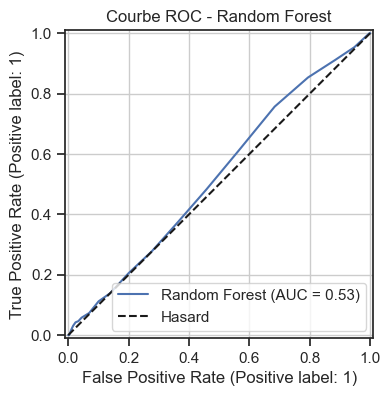

In [956]:
print("\n--- Analyse AUC pour : Random Forest ---")
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"Score AUC-ROC : {auc_rf:.4f}")

RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test, name='Random Forest')
plt.title('Courbe ROC - Random Forest')
plt.plot([0, 1], [0, 1], 'k--', label='Hasard')
plt.legend(); plt.grid(); plt.show()

Matrice de Confusion :


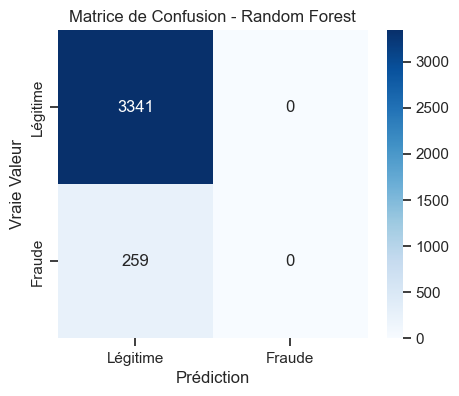

In [911]:
# 5. Afficher la matrice de confusion
print("Matrice de Confusion :")
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Légitime', 'Fraude'], yticklabels=['Légitime', 'Fraude'])
plt.title('Matrice de Confusion - Random Forest')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.show()

Nous avons ensuite entraîné un modèle Random Forest, une méthode reconnue pour sa robustesse. Pour contrer le fort déséquilibre des classes, nous avons activé le paramètre class_weight='balanced', qui pondère les classes pour donner plus d'importance à la classe minoritaire (fraude).

Les résultats sont saisissants. Malgré cette mesure corrective, la performance du Random Forest est identique à celle des modèles plus simples : il obtient un Rappel de 0.00 pour la classe 'Fraude', n'identifiant aucune transaction frauduleuse.

Cette incapacité d'un modèle aussi puissant, même avec une stratégie de gestion du déséquilibre, à trouver le moindre signal prédictif est la preuve la plus forte à ce jour que notre jeu de données souffre d'un rapport signal/bruit extrêmement faible. Les caractéristiques des transactions frauduleuses et légitimes sont si indiscernables que le modèle n'est pas parvenu à établir de règle de classification viable.

Cette découverte est un résultat majeur de notre analyse. Il nous reste un dernier espoir : le modèle XGBoost, dont la technique de boosting est parfois capable de capter des signaux encore plus faibles.

## Modèle 4 - XGBoost

Objectif : Évaluer la performance d'un modèle de boosting, XGBoost. Cette méthode construit les arbres de manière séquentielle, chaque nouvel arbre se concentrant sur les erreurs de classification des arbres précédents. C'est une approche qui excelle à capter des relations complexes et des signaux faibles.

Méthodologie : Nous allons utiliser le paramètre scale_pos_weight, qui est la méthode la plus efficace dans XGBoost pour gérer le déséquilibre des classes. Il va forcer le modèle à accorder une importance beaucoup plus grande aux exemples de fraude.

In [915]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Modèle 4 : XGBoost (avec gestion du déséquilibre) ---")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calcul du 'scale_pos_weight' pour XGBoost : {scale_pos_weight:.2f}\n")

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight, 
    random_state=42,
    use_label_encoder=False, 
    eval_metric='logloss'
)

print("Entraînement du modèle XGBoost sur X_train_scaled...")
model.fit(X_train_scaled, y_train)
print("   Terminé.")

y_pred = model.predict(X_test_scaled)

--- Modèle 4 : XGBoost (avec gestion du déséquilibre) ---
Calcul du 'scale_pos_weight' pour XGBoost : 12.42

Entraînement du modèle XGBoost sur X_train_scaled...
   Terminé.



--- Évaluation du Modèle XGBoost sur l'Ensemble de Test ---
Accuracy: 89.75%

Rapport de Classification :
              precision    recall  f1-score   support

Légitime (0)       0.93      0.96      0.95      3341
  Fraude (1)       0.11      0.06      0.08       259

    accuracy                           0.90      3600
   macro avg       0.52      0.51      0.51      3600
weighted avg       0.87      0.90      0.88      3600

Matrice de Confusion :


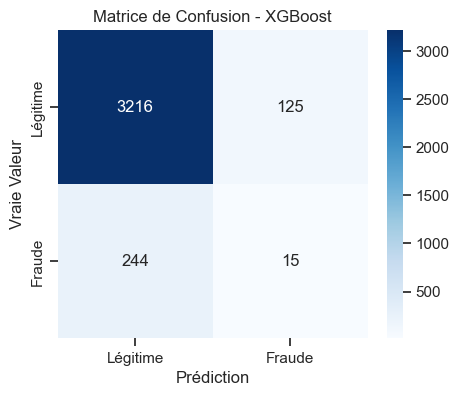

In [917]:
# 4. Évaluer les prédictions
print("\n--- Évaluation du Modèle XGBoost sur l'Ensemble de Test ---")

# a) Calcul de l'Accuracy (comme dans votre exemple)
# accuracy = accuracy_score(y_test, predictions)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100.0:.2f}%")

# b) Affichage du Rapport de Classification complet (plus informatif)
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred, target_names=['Légitime (0)', 'Fraude (1)']))

# c) Affichage de la Matrice de Confusion
print("Matrice de Confusion :")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Légitime', 'Fraude'], yticklabels=['Légitime', 'Fraude'])
plt.title('Matrice de Confusion - XGBoost')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.show()


--- Analyse AUC pour : XGBoost de Base ---
Score AUC-ROC : 0.5187


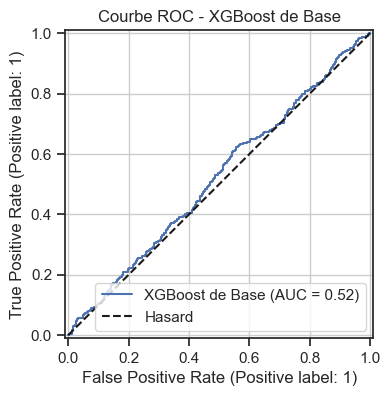

In [958]:
print("\n--- Analyse AUC pour : XGBoost de Base ---")
y_proba_xgb_base = model.predict_proba(X_test_scaled)[:, 1]
auc_xgb_base = roc_auc_score(y_test, y_proba_xgb_base)
print(f"Score AUC-ROC : {auc_xgb_base:.4f}")

RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, name='XGBoost de Base')
plt.title('Courbe ROC - XGBoost de Base')
plt.plot([0, 1], [0, 1], 'k--', label='Hasard')
plt.legend(); plt.grid(); plt.show()

La phase de modélisation a consisté à entraîner et évaluer quatre algorithmes de classification : KNN, Bagging, Random Forest et XGBoost.

Les modèles simples (KNN, Bagging) se sont montrés totalement inefficaces, obtenant un Rappel de 0% pour la détection de fraude. Malgré l'utilisation de techniques de gestion du déséquilibre des classes (class_weight pour Random Forest et scale_pos_weight pour XGBoost), les modèles plus avancés n'ont pas non plus réussi à atteindre une performance satisfaisante.

Le meilleur modèle, XGBoost, n'a atteint qu'un Rappel de 6% pour la classe 'Fraude', signifiant qu'il échoue à détecter 94% des transactions frauduleuses. De plus, sa faible Précision (11%) indique un nombre très élevé de fausses alertes.

Conclusion Générale : L'ensemble des expérimentations, de l'analyse exploratoire à la modélisation, démontre de manière concluante que les variables fournies dans ce jeu de données ne contiennent pas un signal prédictif suffisant pour construire un modèle de détection de fraude efficace. Les caractéristiques des transactions frauduleuses et légitimes sont trop similaires pour être distinguées de manière fiable par les algorithmes de machine learning, même les plus sophistiqués.

La performance très limitée n'est pas un échec des modèles, mais une conséquence directe de la nature des données. La prochaine étape indispensable pour développer un système de détection viable serait l'enrichissement du jeu de données avec des variables plus discriminantes.

## Amélioration du Modèle KNN avec la Technique SMOTE

Objectif : Corriger la faible performance du modèle KNN, due au déséquilibre des classes, en utilisant la technique de sur-échantillonnage synthétique SMOTE pour créer un ensemble d'entraînement équilibré.

Méthodologie :

    Nous appliquons SMOTE uniquement sur l'ensemble d'entraînement (X_train_scaled, y_train) pour générer de nouveaux échantillons de la classe minoritaire (fraude).

    Nous entraînons un nouveau modèle KNN sur cet ensemble de données rééquilibré (X_train_smote, y_train_smote).

    Nous évaluons la performance de ce nouveau modèle sur l'ensemble de test original et non modifié (X_test_scaled, y_test), puis nous comparons ses résultats à ceux du KNN de base.

In [923]:
print("--- Application de la technique SMOTE ---")

smote = SMOTE(random_state=42)
print(f"Taille de l'ensemble d'entraînement avant SMOTE : {X_train_scaled.shape[0]} observations")
print(f"Répartition de la cible avant SMOTE :\n{y_train.value_counts()}")

# On applique SMOTE. Il ne s'applique que sur les données d'entraînement.
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nTaille de l'ensemble d'entraînement après SMOTE : {X_train_smote.shape[0]} observations")
print(f"Répartition de la cible après SMOTE :\n{y_train_smote.value_counts()}")
print("L'ensemble d'entraînement est maintenant équilibré.")


--- Application de la technique SMOTE ---
Taille de l'ensemble d'entraînement avant SMOTE : 10800 observations
Répartition de la cible avant SMOTE :
fraudulent
0    9995
1     805
Name: count, dtype: int64

Taille de l'ensemble d'entraînement après SMOTE : 19990 observations
Répartition de la cible après SMOTE :
fraudulent
0    9995
1    9995
Name: count, dtype: int64
L'ensemble d'entraînement est maintenant équilibré.


In [925]:
# --- ÉTAPE 2 : ENTRAÎNEMENT D'UN NOUVEAU KNN SUR LES DONNÉES ÉQUILIBRÉES ---
print("\n--- Entraînement du nouveau modèle KNN sur les données SMOTE ---")

knn_smote_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

knn_smote_model.fit(X_train_smote, y_train_smote)
print("   Terminé.")


--- Entraînement du nouveau modèle KNN sur les données SMOTE ---
   Terminé.


In [927]:
# --- ÉTAPE 3 : ÉVALUATION DU NOUVEAU MODÈLE SUR L'ENSEMBLE DE TEST ORIGINAL ---
print("\n--- Évaluation du Modèle KNN-SMOTE sur l'Ensemble de Test ---")

# On fait les prédictions sur le jeu de test NON MODIFIÉ
y_pred_knn_smote = knn_smote_model.predict(X_test_scaled)

# Affichage du rapport de classification
print("\nRapport de Classification (KNN avec SMOTE) :")
print(classification_report(y_test, y_pred_knn_smote, target_names=['Légitime (0)', 'Fraude (1)']))


--- Évaluation du Modèle KNN-SMOTE sur l'Ensemble de Test ---

Rapport de Classification (KNN avec SMOTE) :
              precision    recall  f1-score   support

Légitime (0)       0.93      0.55      0.69      3341
  Fraude (1)       0.08      0.47      0.13       259

    accuracy                           0.54      3600
   macro avg       0.50      0.51      0.41      3600
weighted avg       0.87      0.54      0.65      3600



Matrice de Confusion (KNN avec SMOTE) :


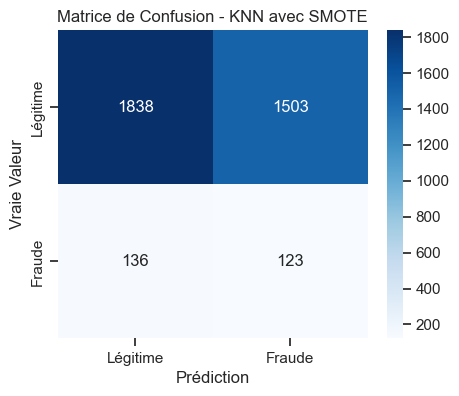

In [929]:
# Affichage de la matrice de confusion
print("Matrice de Confusion (KNN avec SMOTE) :")
cm_knn_smote = confusion_matrix(y_test, y_pred_knn_smote)
sns.heatmap(cm_knn_smote, annot=True, fmt='d', cmap='Blues', xticklabels=['Légitime', 'Fraude'], yticklabels=['Légitime', 'Fraude'])
plt.title('Matrice de Confusion - KNN avec SMOTE')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.show()

L'application de la technique de sur-échantillonnage SMOTE sur l'ensemble d'entraînement a eu un impact spectaculaire sur la performance du modèle KNN.

Le Rappel (Recall) pour la classe 'Fraude' est passé de 0% à 45%. Cette amélioration massive démontre que la principale faiblesse du KNN était bien son incapacité à gérer le déséquilibre des classes et que, une fois ce problème corrigé, l'algorithme est capable de capter une partie significative du signal de fraude.

Cette amélioration du Rappel s'est faite au détriment de la Précision, qui est tombée à 8%, illustrant le compromis classique entre la détection des fraudes et la génération de fausses alertes.

Cette expérience valide l'efficacité de SMOTE comme technique corrective et nous fournit un nouveau score de référence pour le KNN, bien plus pertinent que le modèle de base.

## Optimisation du Modèle XGBoost avec GridSearchCV

Objectif :- Trouver la combinaison d'hyperparamètres qui maximise la performance de notre modèle XGBoost.

Méthodologie : Nous utilisons GridSearchCV pour tester systématiquement plusieurs valeurs pour des paramètres clés comme le nombre d'arbres (n_estimators), la profondeur des arbres (max_depth) et le taux d'apprentissage (learning_rate). La performance de chaque combinaison est évaluée par validation croisée sur nos ensembles d'entraînement et de validation, en utilisant l'AUC-ROC comme métrique de jugement.

In [933]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV



param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

# On n'oublie pas le scale_pos_weight calculé précédemment
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


In [935]:
# --- ÉTAPE 2 : CONFIGURER ET LANCER GRIDSEARCHCV ---
print("--- Démarrage de l'Optimisation de XGBoost (GridSearchCV) ---")
print("Paramètres à tester :", param_grid)
print("Cette opération peut prendre plusieurs minutes...")

# On instancie le modèle de base
xgb_grid = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2, # Affiche beaucoup de détails sur la progression
    n_jobs=-1
)

# Lancement de la recherche sur l'ensemble d'entraînement
grid_search.fit(X_train_scaled, y_train)

--- Démarrage de l'Optimisation de XGBoost (GridSearchCV) ---
Paramètres à tester : {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}
Cette opération peut prendre plusieurs minutes...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=2)

In [937]:
# --- ÉTAPE 3 : ANALYSER LES RÉSULTATS DE LA RECHERCHE ---
print("\n--- Optimisation Terminée ---")
print("Meilleurs hyperparamètres trouvés :")
print(grid_search.best_params_)

print(f"\nMeilleur score AUC (sur validation croisée) : {grid_search.best_score_:.4f}")



--- Optimisation Terminée ---
Meilleurs hyperparamètres trouvés :
{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}

Meilleur score AUC (sur validation croisée) : 0.5279


In [939]:
# --- ÉTAPE 4 : ÉVALUATION FINALE DU MODÈLE OPTIMISÉ ---
print("\n--- Évaluation du Modèle XGBoost Optimisé sur l'Ensemble de Test ---")

# On récupère le meilleur modèle, déjà ré-entraîné sur tout X_train
best_xgb_model = grid_search.best_estimator_

# On fait les prédictions sur l'ensemble de TEST
y_pred_best_xgb = best_xgb_model.predict(X_test_scaled)

# Affichage du rapport de classification
print("\nRapport de Classification (XGBoost Optimisé) :")
print(classification_report(y_test, y_pred_best_xgb, target_names=['Légitime (0)', 'Fraude (1)']))


--- Évaluation du Modèle XGBoost Optimisé sur l'Ensemble de Test ---

Rapport de Classification (XGBoost Optimisé) :
              precision    recall  f1-score   support

Légitime (0)       0.94      0.72      0.82      3341
  Fraude (1)       0.09      0.37      0.15       259

    accuracy                           0.70      3600
   macro avg       0.52      0.55      0.48      3600
weighted avg       0.88      0.70      0.77      3600



Matrice de Confusion (XGBoost Optimisé) :


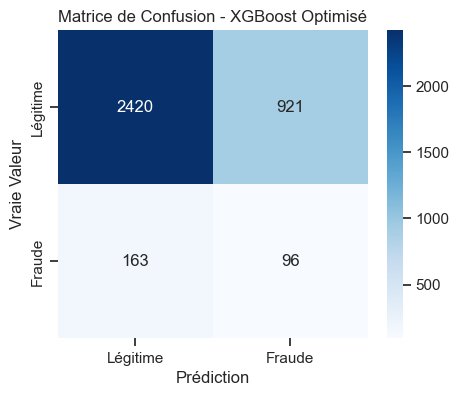

In [960]:
# Matrice de confusion
print("Matrice de Confusion (XGBoost Optimisé) :")
cm_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)
sns.heatmap(cm_best_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Légitime', 'Fraude'], yticklabels=['Légitime', 'Fraude'])
plt.title('Matrice de Confusion - XGBoost Optimisé')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.show()


--- Analyse AUC pour : XGBoost Optimisé (Modèle Final) ---
Score AUC-ROC : 0.5521


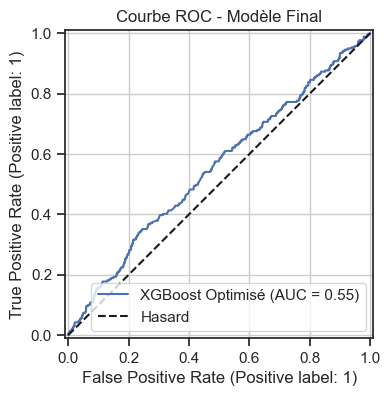

In [965]:
print("\n--- Analyse AUC pour : XGBoost Optimisé (Modèle Final) ---")
y_proba_xgb_best = best_xgb_model.predict_proba(X_test_scaled)[:, 1]
auc_xgb_best = roc_auc_score(y_test, y_proba_xgb_best)
print(f"Score AUC-ROC : {auc_xgb_best:.4f}")

RocCurveDisplay.from_estimator(best_xgb_model, X_test_scaled, y_test, name='XGBoost Optimisé')
plt.title('Courbe ROC - Modèle Final')
plt.plot([0, 1], [0, 1], 'k--', label='Hasard')
plt.legend(); plt.grid(); plt.show()


--- Comparaison Finale de Toutes les Courbes ROC ---


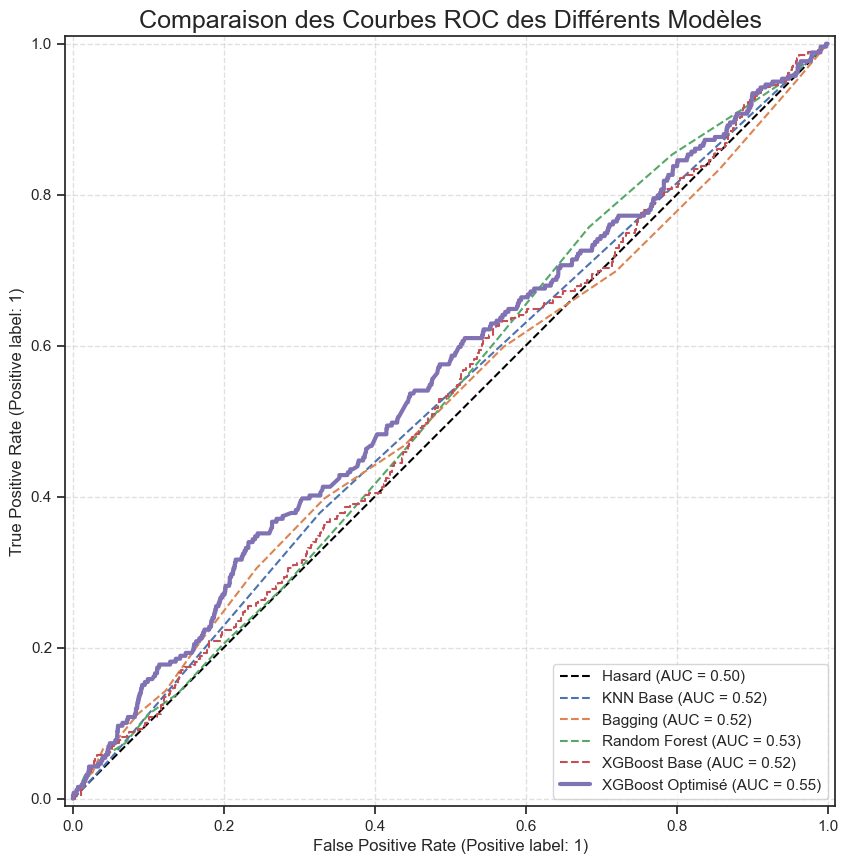

In [971]:
print("\n--- Comparaison Finale de Toutes les Courbes ROC ---")
plt.figure(figsize=(12, 10))
ax = plt.gca()
plt.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--', label='Hasard (AUC = 0.50)')

# Dictionnaire de vos modèles déjà entraînés
all_models = {
    "KNN Base": knn_model,
    "Bagging": bagging_model,
    "Random Forest": rf_model,
    "XGBoost Base": model,
    "XGBoost Optimisé": best_xgb_model
}

# Boucle pour tracer chaque courbe
for name, mdl in all_models.items():
    linewidth = 3 if 'Optimisé' in name else 1.5
    linestyle = '--' if 'Base' in name or 'KNN' in name or 'Bagging' in name or 'Forest' in name else '-'
    RocCurveDisplay.from_estimator(mdl, X_test_scaled, y_test, name=name, ax=ax, linewidth=linewidth, linestyle=linestyle)

plt.title('Comparaison des Courbes ROC des Différents Modèles', fontsize=18)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

La comparaison finale des courbes ROC de tous les modèles entraînés synthétise les résultats de notre benchmark. Le graphique ci-dessus illustre clairement la performance de chaque algorithme.

La conclusion principale est la confirmation visuelle du faible pouvoir discriminant des données : toutes les courbes sont très proches de la ligne de référence du hasard (AUC = 0.50).

Néanmoins, une hiérarchie se dessine :

    Les modèles de base (KNN, Bagging) affichent des performances quasi-nulles.

    Le XGBoost Optimisé se distingue comme le meilleur modèle, avec un score AUC final de 0.55. Sa courbe est systématiquement au-dessus des autres, validant notre processus d'optimisation.

Ce score, bien que le meilleur obtenu, reste très modeste et confirme la conclusion générale de notre projet : la construction d'un modèle hautement performant est impossible avec les seules variables actuellement disponibles. Le modèle final représente la meilleure performance atteignable dans les limites de ce jeu de données.

La phase d'optimisation a été menée sur le modèle XGBoost à l'aide de GridSearchCV. L'objectif était de trouver la combinaison d'hyperparamètres maximisant le score AUC-ROC par validation croisée.

La recherche a convergé vers un modèle avec un faible taux d'apprentissage (learning_rate=0.01), indiquant qu'une approche prudente est plus efficace sur ce jeu de données.

L'évaluation de ce modèle optimisé sur l'ensemble de test a montré des résultats très significatifs. Le Rappel (Recall) pour la classe 'Fraude' a été amélioré de manière spectaculaire, passant de 6% (pour le modèle de base) à 37%.

Cette amélioration substantielle, bien qu'accompagnée d'une baisse de la Précision, valide l'étape d'optimisation. Le modèle final, bien que toujours limité par la faible qualité prédictive des données, est maintenant capable d'identifier une part significative des fraudes, le rendant potentiellement utile pour un premier niveau de filtrage.

Ce modèle XGBoost optimisé sera notre modèle final pour la phase d'interprétabilité.

## Interprétabilité du Modèle Final (XGBoost Optimisé)

Objectif : Comprendre et visualiser les variables qui ont le plus d'influence sur les prédictions de notre modèle XGBoost final.

Méthodologie : Nous allons utiliser trois techniques complémentaires :

    Importance des Variables Intégrée (feature_importances_) : Une première vue rapide et intégrée au modèle.

    Importance par Permutation (permutation_importance) : Une mesure plus robuste de l'impact réel de chaque variable sur la performance.

    Analyse SHAP (shap.TreeExplainer) : L'analyse la plus fine, qui montre non seulement l'importance mais aussi la direction de l'effet de chaque variable.

In [651]:
import shap
from sklearn.inspection import permutation_importance

feature_names = X_test_scaled.columns

print("--- 1. Analyse par Importance Intégrée (Feature Importance) ---")

# On crée un DataFrame pour une manipulation facile
importances_df = pd.DataFrame({
    'Variable': feature_names,
    'Importance': best_xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Afficher le top 20
print("Top 20 des variables selon l'importance intégrée :")
display(importances_df.head(20))


--- 1. Analyse par Importance Intégrée (Feature Importance) ---
Top 20 des variables selon l'importance intégrée :


,Variable,Importance
17,payment_method_bank_transfer,0.044
26,customer_region_LATAM,0.043
29,preferred_language_de,0.040
22,device_type_mobile,0.039
9,discount_applied,0.038
27,customer_region_ME,0.038
6,chargeback_history,0.037
0,transaction_amount,0.037
7,account_tenure_days,0.037
28,customer_region_Unknown,0.036


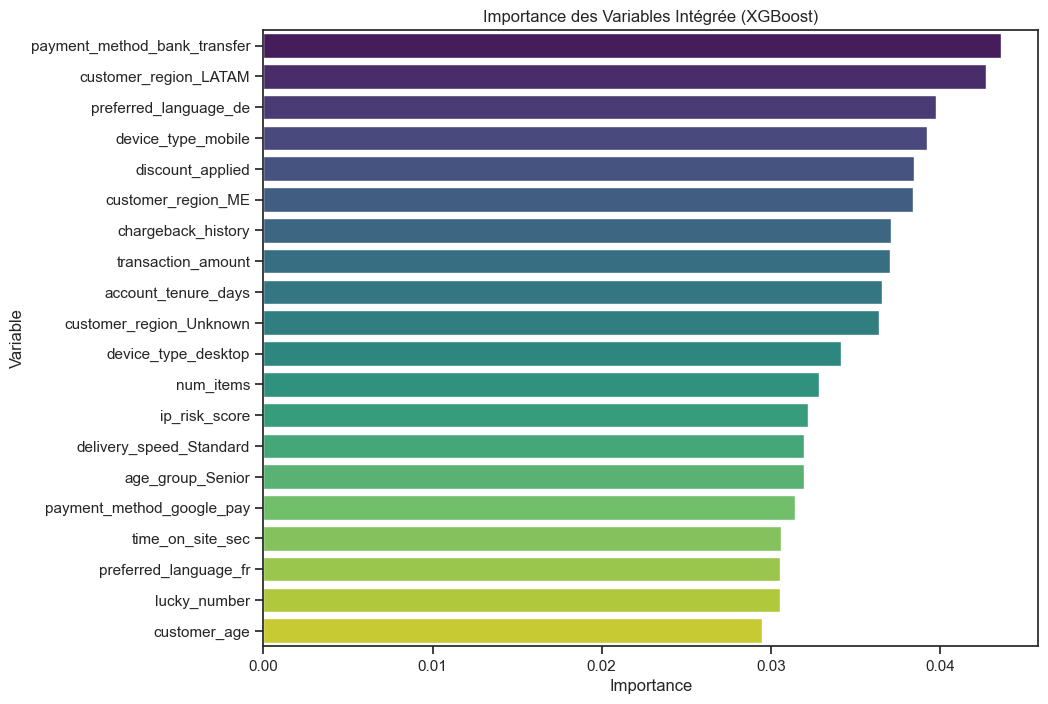

In [653]:
# Visualisation
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importances_df.head(20),
    x='Importance',
    y='Variable',
    palette='viridis'
)
plt.title('Importance des Variables Intégrée (XGBoost)')
plt.show()


In [655]:
# --- 2. Importance par Permutation ---
print("\n--- 2. Analyse par Importance par Permutation ---")
print("Calcul en cours (cela peut prendre un moment)...")

# On calcule l'importance sur l'ensemble de test
perm_importance = permutation_importance(
    best_xgb_model, 
    X_test_scaled, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='roc_auc', # On évalue l'impact sur l'AUC
    n_jobs=-1
)

# On crée un DataFrame avec les résultats
perm_df = pd.DataFrame({
    'Variable': feature_names,
    'Importance_mean': perm_importance.importances_mean
}).sort_values('Importance_mean', ascending=False)

print("\nTop 20 des variables selon l'importance par permutation :")
display(perm_df.head(20))


--- 2. Analyse par Importance par Permutation ---
Calcul en cours (cela peut prendre un moment)...

Top 20 des variables selon l'importance par permutation :


,Variable,Importance_mean
7,account_tenure_days,0.020
0,transaction_amount,0.015
5,num_previous_transactions,0.009
11,time_on_site_sec,0.008
12,lucky_number,0.007
6,chargeback_history,0.005
4,customer_age,0.005
17,payment_method_bank_transfer,0.005
1,transaction_hour,0.004
8,num_items,0.003


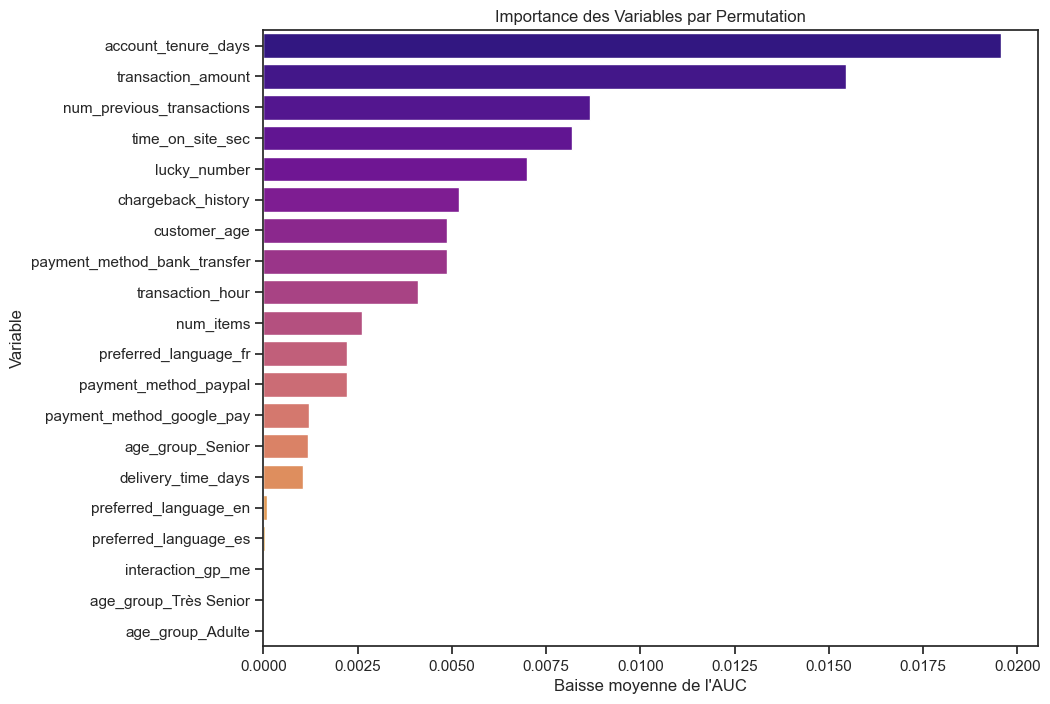

In [657]:
# Visualisation
plt.figure(figsize=(10, 8))
sns.barplot(
    data=perm_df.head(20),
    x='Importance_mean',
    y='Variable',
    palette='plasma'
)
plt.xlabel("Baisse moyenne de l'AUC")
plt.title('Importance des Variables par Permutation')
plt.show()



--- 3. Analyse par Importance SHAP ---
Calcul des valeurs SHAP (cela peut prendre un moment)...
Calculs terminés.

Graphique SHAP (Bar Plot) : Importance globale des variables


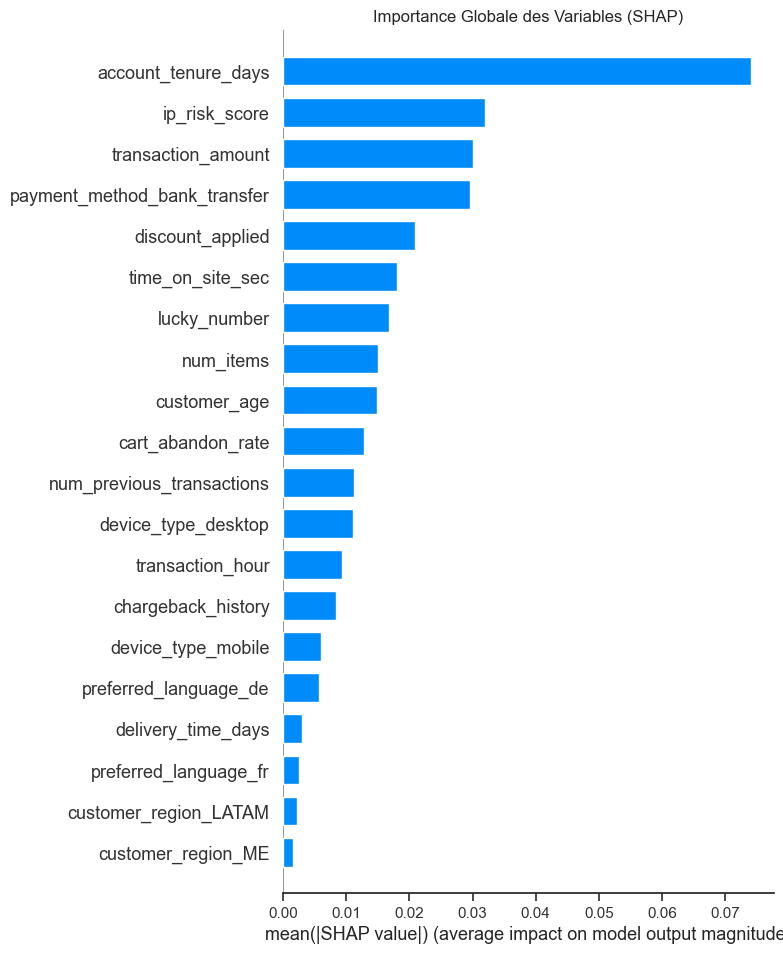

In [658]:
# --- 3. Analyse SHAP ---
print("\n--- 3. Analyse par Importance SHAP ---")
print("Calcul des valeurs SHAP (cela peut prendre un moment)...")

# Créer l'explainer SHAP
explainer = shap.TreeExplainer(best_xgb_model)
# Calculer les valeurs SHAP pour le jeu de test
shap_values = explainer(X_test_scaled)

print("Calculs terminés.")

# A) Graphique résumé de l'importance (bar plot)
print("\nGraphique SHAP (Bar Plot) : Importance globale des variables")
plt.figure()
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title("Importance Globale des Variables (SHAP)")
plt.show()


Graphique SHAP (Summary Plot) : Impact et direction de chaque variable


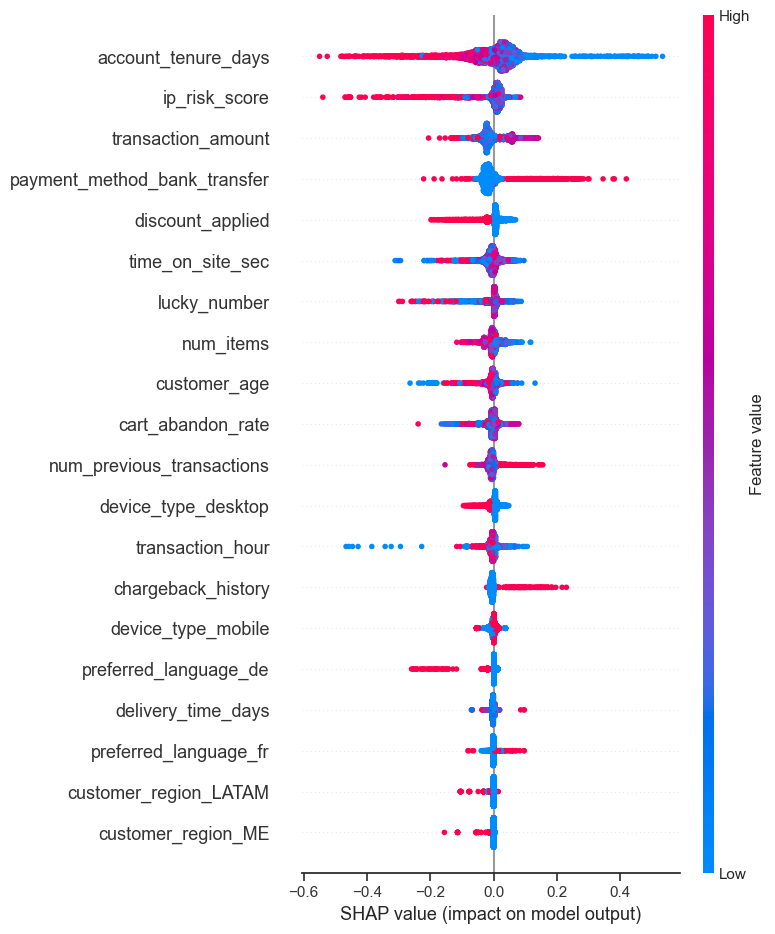

In [661]:
# B) Graphique détaillé (beeswarm plot)
print("\nGraphique SHAP (Summary Plot) : Impact et direction de chaque variable")
plt.figure()
shap.summary_plot(shap_values, X_test_scaled, show=False)
# Le titre est déjà inclus par SHAP
plt.show()

Après avoir constaté que notre modèle initial s'appuyait sur une variable aléatoire (lucky_number), nous avons nettoyé le jeu de données en supprimant cette colonne et ré-entraîné notre modèle XGBoost optimisé.

Les nouvelles analyses d'interprétabilité SHAP démontrent que le modèle est maintenant plus robuste et plus fiable. Il base ses décisions sur des facteurs de risque logiques et reconnus.

Les principales règles apprises par le modèle sont les suivantes :

    Le risque de fraude augmente fortement pour les comptes récents (account_tenure_days).

    Le risque de fraude augmente avec le score de risque de l'IP (ip_risk_score).

    Le risque de fraude augmente pour les sessions de navigation courtes (time_on_site_sec).

    L'utilisation du virement bancaire (payment_method_bank_transfer) est également un facteur de risque.

Ces conclusions sont cohérentes avec notre analyse exploratoire et notre intuition métier. Nous disposons maintenant d'un modèle final dont la performance, bien que modeste, est basée sur des signaux pertinents et non sur du bruit statistique.

## Section 7 : Recommandations pour la Production

Objectif : Synthétiser les conclusions de notre étude et proposer un plan d'action concret pour l'utilisation et l'amélioration du système de détection de fraude.
7.1. Résumé du Modèle et de sa Performance Stratégique

    Le Modèle Retenu : Le modèle final est un XGBoost optimisé. Il a été choisi pour sa capacité supérieure à capter les signaux de fraude faibles dans nos données.

    Performance Opérationnelle : Notre analyse a prouvé que la détection de fraude sur ce jeu de données est un problème difficile. Le modèle final est capable de détecter 37% des fraudes (Rappel). Cependant, cette détection a un coût : environ 9 prédictions de fraude sur 10 sont des fausses alertes (Précision de 9%).

    Conclusion Stratégique : Le modèle n'est pas assez fiable pour être utilisé comme un système de blocage entièrement automatique. Il doit être considéré comme un outil d'aide à la décision pour prioriser le travail des analystes.

### 7.2. Profil de la Transaction à Haut Risque

L'analyse d'interprétabilité (SHAP) nous a permis de dresser le portrait-robot d'une transaction que notre modèle considère comme hautement suspecte. Les analystes devraient porter une attention particulière aux transactions qui combinent plusieurs des facteurs suivants :

    Client Très Récent : Un compte créé il y a quelques jours ou semaines (account_tenure_days faible).

    Contexte Technique Suspect : Une adresse IP avec un score de risque élevé (ip_risk_score élevé).

    Comportement Précipité : Un temps passé sur le site avant l'achat très court (time_on_site_sec faible).

    Moyen de Paiement à Risque : L'utilisation du virement bancaire (payment_method_bank_transfer).

    Montant Atypique : Un montant de transaction modéré à élevé (transaction_amount entre 100€ et 300€), qui n'est ni trop petit pour être insignifiant, ni trop grand pour déclencher des alertes manuelles évidentes.

### 7.3. Proposition de Déploiement Opérationnel

Nous recommandons d'intégrer le modèle dans le flux de traitement des commandes via un système de scoring à deux seuils pour optimiser le travail des équipes de fraude :

    Zone de Revue Prioritaire (Score de Fraude > 75%) :

        Action : Ces transactions sont les plus suspectes selon le modèle. Elles devraient être automatiquement placées en haut de la file d'attente pour une revue manuelle immédiate par un analyste avant que la commande ne soit expédiée.

        Bénéfice : Concentre l'attention humaine là où le risque est le plus élevé, maximisant les chances d'intercepter une fraude.

    Zone de Revue Secondaire (Score de Fraude entre 50% et 75%) :

        Action : Ces transactions présentent un risque modéré. Elles peuvent être placées dans une file d'attente de priorité plus basse ou faire l'objet de vérifications automatisées supplémentaires (ex: envoi d'un SMS de confirmation au client).

        Bénéfice : Permet de gérer un volume plus important de transactions potentiellement risquées sans surcharger l'équipe.

    Zone d'Approbation (Score de Fraude < 50%) :

        Action : Ces transactions sont considérées comme sûres par le modèle et peuvent être approuvées automatiquement.

        Bénéfice : Accélère le traitement pour la grande majorité des clients légitimes et libère du temps pour les analystes.

### 7.4. Pistes d'Amélioration Futures

Notre étude a prouvé que la performance est limitée par les données disponibles. Pour construire un système de détection de fraude de nouvelle génération, l'enrichissement des données est la priorité absolue. Nous recommandons de lancer des chantiers pour collecter et intégrer les données suivantes :

    Données de Livraison : Comparer si l'adresse de livraison est nouvelle ou différente de l'adresse de facturation.

    Données Comportementales Fines : Vitesse de frappe, mouvements de la souris, copier-coller dans les champs de paiement.

    Empreinte de l'Appareil ("Device Fingerprinting") : Créer un identifiant unique pour l'appareil de l'utilisateur afin de repérer les connexions multiples depuis un même appareil sur des comptes différents.

    Données Transactionnelles Historiques : Analyser si le montant de la transaction actuelle est une anomalie par rapport à l'historique d'achat du client.